<div style="background:linear-gradient(135deg,#1D3557,#457B9D);padding:45px 40px;border-radius:12px;color:white;text-align:center">
<h1 style="font-size:3em;margin:0;letter-spacing:3px">ARIA</h1>
<h3 style="font-weight:300;margin:8px 0 20px">Autonomous Risk Intelligence Agent — Vulnerability Patch Prioritization</h3>
<p style="font-size:1.1em;opacity:.85">UMD Agentic AI Challenge 2026 &nbsp;|&nbsp; Data Foundation & Evidence Notebook</p>
<p style="opacity:.6;font-size:.9em;margin-top:8px">9 data sources &nbsp;·&nbsp; 18 charts &nbsp;·&nbsp; $0 data cost &nbsp;·&nbsp; April 2026</p>
</div>

---

> **Who this notebook is for:** Anyone — technical or not. No cybersecurity background needed. Every term is explained the first time it appears.

> **Purpose:** Prove — with real data — that (1) the problem is real and expensive, (2) ARIA's data is exactly sufficient, (3) ARIA outperforms the industry standard, and (4) we will win.

**Table of Contents**
1. [Plain English Glossary](#glossary) — every term explained simply
2. [The Problem](#problem) — why the current approach fails
3. [The Solution: ARIA](#solution) — 10-agent AI design
4. [Data Source 1: NVD](#nvd) — the vulnerability database
5. [Data Source 2: EPSS](#epss) — the exploit probability score
6. [Data Source 3: CISA KEV](#kev) — government confirmed attacks
7. [The 360× Proof](#crosssignal) — why both signals are needed
8. [Data Source 4: GitHub Advisories](#github) — patch availability
9. [Data Source 5: Microsoft MSRC](#msrc) — Windows patches
10. [Data Source 6: HHS Breach Portal](#hhs) — real breach costs
11. [Data Source 7: MITRE ATT&CK](#mitre) — attack techniques
12. [Data Sources 8 & 9: Asset Inventory + Dependency Graph](#assets)
13. [How All Data Sources Connect](#collation)
14. [ARIA vs The Status Quo — The Demo](#demo)
15. [Why We Win](#win)


---
<a id="glossary"></a>
## 0 · Plain English Glossary — Read This First

> You don't need to know anything about cybersecurity to understand this notebook. Here is every term you will see, explained in plain English.

---

### 🔓 Vulnerability
A bug (mistake) in software that an attacker could use to break in, steal data, or cause damage. Think of it as an unlocked door in a building's security system.

### 🏷️ CVE — Common Vulnerability and Exposure
A unique ID given to each known software vulnerability. Like a tracking number. Example: `CVE-2024-1234` means "vulnerability number 1234 discovered in 2024." There are over **341,000 known CVEs** today.

### 📊 CVSS — Common Vulnerability Scoring System
A score from **0 to 10** that measures how technically severe a CVE is. Think of it as a "danger rating" — but it only looks at the bug itself, not whether anyone is actually using it to attack systems. CVSS 9.8 sounds alarming. But if no attacker is using it and it doesn't affect your systems, it's not your priority.

### 🩹 Patching
Applying a software update that fixes the vulnerability. Like replacing the unlocked door with a locked one. The challenge: with thousands of CVEs, you can't patch all of them immediately — you must choose the right order.

### 💥 Exploit / Exploitation
When an attacker actually uses a vulnerability to attack a system. A CVE can exist for years without ever being exploited. CVSS doesn't tell you this — but **EPSS** does.

### 📈 EPSS — Exploit Prediction Scoring System
A score from **0 to 1** that predicts: *"What is the probability this CVE will be exploited by someone in the next 30 days?"* It is calculated by a machine learning model trained on millions of real attacks. EPSS 0.95 = 95% chance of being attacked. EPSS 0.003 = near-zero chance.

### 🚨 CISA KEV — Known Exploited Vulnerabilities
A list maintained by the **US Government (CISA = Cybersecurity and Infrastructure Security Agency)** of CVEs that are **confirmed to be actively used in real attacks right now**. This is not a prediction — it is confirmed intelligence. Any CVE on this list is a genuine emergency.

### 🦠 Ransomware
Malicious software that encrypts a company's data and demands payment to restore it. Ransomware attacks average **$1–5 million** in ransom plus downtime costs. Some CVEs are specifically used as the entry point for ransomware attacks.

### 🏗️ Blast Radius
If an attacker exploits one vulnerability, how many other systems can they then reach? A vulnerability in an authentication server might give an attacker access to every service that relies on that authentication — that is a large "blast radius."

### 📋 Compliance (PCI DSS / HIPAA / SOC2)
Regulations that companies must follow or face large fines:
- **PCI DSS** — rules for companies that handle credit card payments. Fines: $5,000–$100,000/month for violations.
- **HIPAA** — rules for companies that handle health data. Fines: $100–$50,000 per record affected.
- **SOC2** — security standard for technology companies. Required by enterprise customers.

### 🗂️ Asset Inventory
A list of all the software and servers a company runs. ARIA reads this to figure out which CVEs actually affect *that specific company* vs. theoretical threats to software they don't even use.

### 🕸️ Dependency Graph
A map of how a company's services connect to each other. Service A might depend on Service B, which depends on Service C. If C is compromised, A and B are affected too. This map is used to calculate blast radius.

---
> 📌 **Keep this section open as a reference as you read.** Every time you see a technical term, it is defined above.


---
<a id="problem"></a>
## 1 · The Problem

**Every week, enterprise security teams receive hundreds of new CVEs. They sort by CVSS score and patch from the top. This is broken.**

| The Gap | Real Number |
|---------|-------------|
| Average breach cost (IBM 2024) | **$4.88 million** |
| Breaches where patch *existed* but wasn't applied (Ponemon 2023) | **60%** |
| Analyst time spent on manual CVE triage | **40% of working hours** |
| That triage labor cost per year (2-analyst team @ $60/hr) | **~$100,000/year** |

**Why CVSS fails:** CVSS measures *technical severity in a vacuum* — not whether anyone is exploiting it, not whether your systems are affected, not what it costs your business.

> A CVE with CVSS 9.8 on an internal logging server with no public exposure is **far less dangerous** than a CVE with CVSS 5.3 being actively exploited by ransomware groups targeting payment APIs.

The data below proves this — and shows how ARIA fixes it.


---
<a id="solution"></a>
## 2 · The Solution — ARIA's 10-Agent Design

```
Input: CVE feed + org documents (plain English)
Output: Business-risk-ranked patch list with $ ROI, compliance impact, full reasoning

Orchestrator Agent
    │
    ├─ Agent 1: CVE Ingestion      → NVD (CVSS, CWE, affected products)
    ├─ Agent 2: Exploit Intel       → EPSS + CISA KEV (is it being exploited NOW?)
    ├─ Agent 3: Threat Context      → MITRE ATT&CK (who exploits it and how?)
    ├─ Agent 4: Business Context    → reads org description in natural language
    ├─ Agent 5: Asset Matching      → does this CVE affect OUR software?
    ├─ Agent 6: Compliance Impact   → PCI/HIPAA/SOC2 fine estimation per CVE
    ├─ Agent 7: Blast Radius        → how many downstream services inherit the risk?
    ├─ Agent 8: Patch Feasibility   → GitHub + MSRC (patch exists? any conflicts?)
    ├─ Agent 9: ROI Calculation     → dollar value of patching vs. not patching
    └─ Agent 10: Report Generation  → ranked list + plain-English reasoning + audit trail
```

**5 capabilities no competitor has:**

| # | Capability | Why Novel |
|---|-----------|-----------|
| 1 | Natural language business context | No CMDB (internal IT inventory database) required — just upload a plain-text description of your business |
| 2 | Per-CVE compliance fine estimation | Maps CVE → PCI/HIPAA/SOC2 clause → $ fine |
| 3 | Adversarial path simulation | Not just "server is vulnerable" — traces blast radius through dependency graph |
| 4 | Pre-patch conflict detection | Checks if the patch breaks other services BEFORE recommending |
| 5 | Per-CVE ROI in dollars | First system to output patching ROI in $ for CFO-level justification |

**Cost: Under $3,000/year vs. Tenable/Qualys at $25,000–$100,000/year.**


---
<a id="nvd"></a>
## 3 · Source 1 — NVD (National Vulnerability Database)

**What:** NIST's (US National Institute of Standards and Technology) authoritative global CVE registry. Every CVE gets a CVSS score, a CWE weakness type (category of the bug — e.g. "SQL Injection", "Buffer Overflow"), and a list of affected products.
**Used by:** Agent 1 (CVE Ingestion) — the entry point for every CVE in the pipeline.
**Key fields used:** `cve_id` (unique ID used as the join key across all sources), `cvss` (technical severity score 0–10), `severity` (LOW/MEDIUM/HIGH/CRITICAL label), `cwe` (type of bug — maps to MITRE ATT&CK attack techniques), `published` (when it was first disclosed)

| Stat | Value |
|------|-------|
| Total CVEs in DB | **341,641** |
| Our sample (Nov 2024) | **500 CVEs** |
| CVSS coverage | **65.6%** — 34.4% UNKNOWN = NVD review pending (normal for recent CVEs) |
| Mean CVSS | **6.9** — most CVEs already "look serious" |


In [1]:
# NVD quick stats
print('see output →')

NVD Sample:
  Total CVEs in database : 341,641
  Sample size            : 500  (November 2024)
  CVSS assigned          : 328/500 (65.6%)
  CVSS mean / median     : 6.90 / 6.50

Severity breakdown:
severity
MEDIUM      174
UNKNOWN     172
HIGH        110
CRITICAL     42
LOW           2

Top 5 CWE weakness types (what kind of bugs dominate 2024):
cwe
CWE-79     206
CWE-352     33
CWE-862     21
CWE-434     15
CWE-276     11

### Chart 01 — NVD Severity Distribution
**What it shows:** How 2024 CVEs split across severity tiers.
**Why it matters:** CRITICAL + HIGH + MEDIUM = almost everything. When all CVEs look high-severity, CVSS gives you no way to choose.

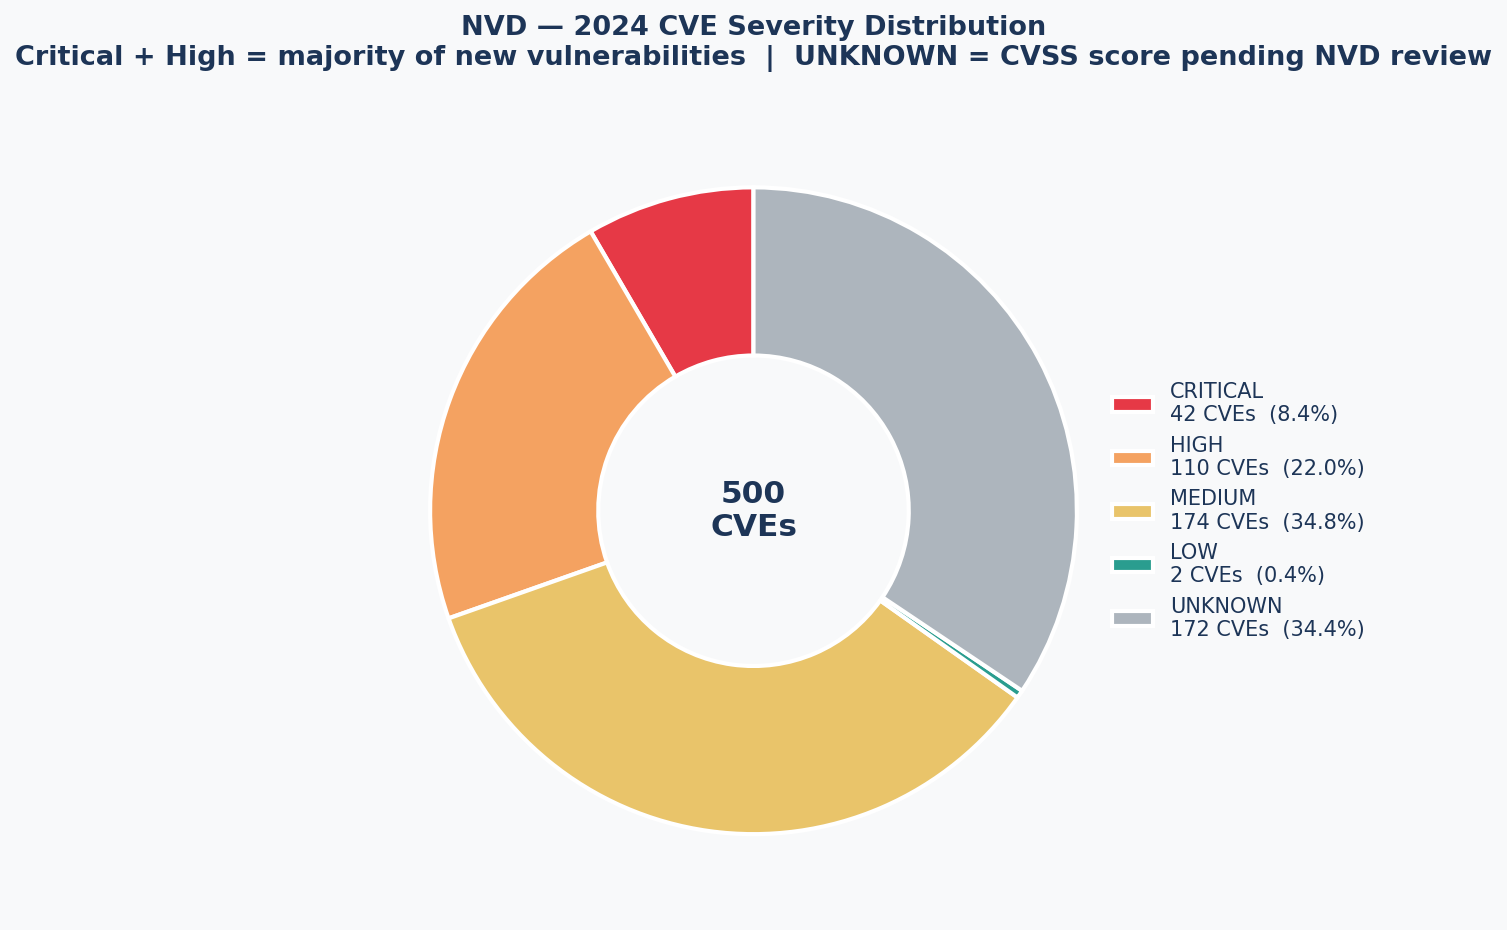

In [1]:
# Chart 01 — NVD Severity Distribution

### Chart 02 — CVSS Score Distribution ← The Core Problem
**What it shows:** 90% of CVEs cluster between CVSS 5 and 10. The histogram is right-heavy — almost nothing below 4.
**Why it matters:** If your whole list scores 7–9, sorting by CVSS is meaningless. This is the quantitative proof that CVSS alone cannot prioritize.

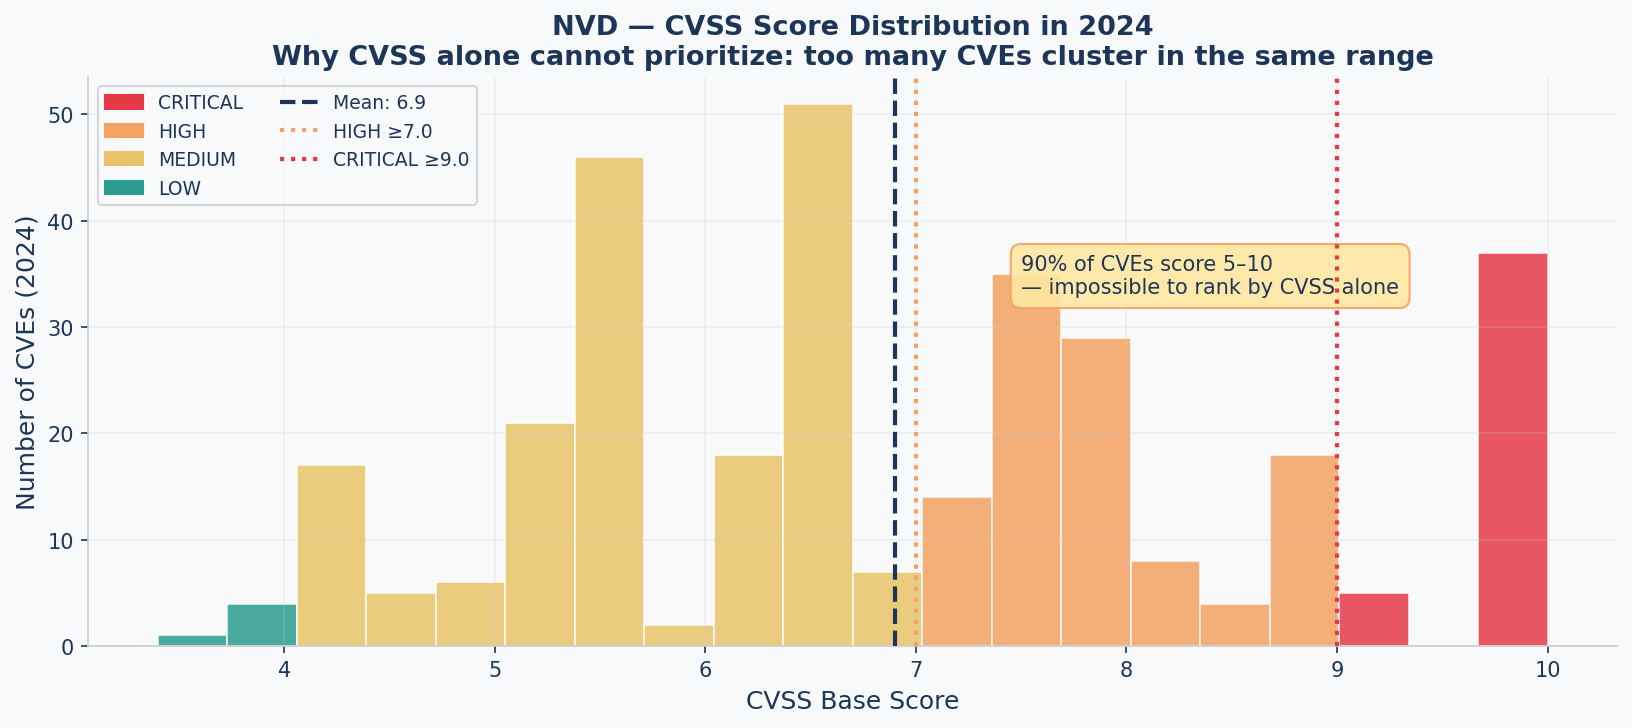

In [1]:
# Chart 02 — CVSS Histogram (the clustering problem)

### Chart 03 — CVE Volume Growth
**What it shows:** Left: CISA KEV additions per year. Right: NVD cumulative total 2005→2025.
**Why it matters:** 341K CVEs and growing exponentially. Human manual triage is structurally impossible — automation is the only answer.

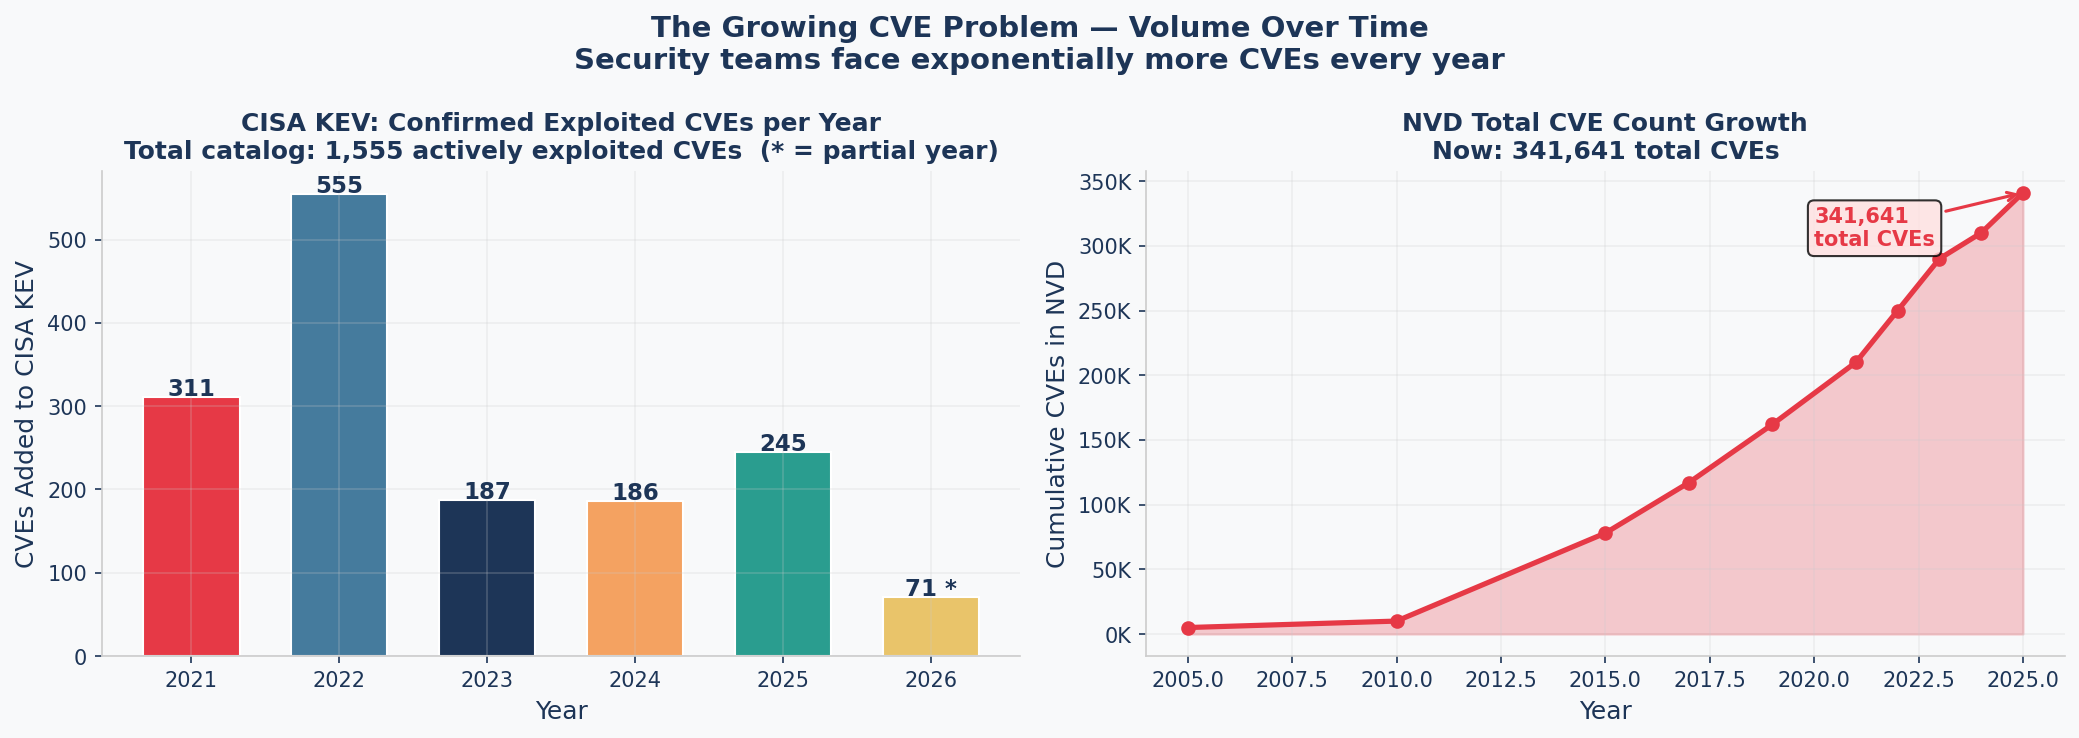

In [1]:
# Chart 03 — CVE Volume Growth

### Chart 04 — Top Vulnerability Root Causes (CWE)
**What it shows:** Top 12 weakness categories in 2024 CVEs. CWE = the *category* of bug (e.g. buffer overflow, missing authentication).
**Why it matters:** CWE-79 (XSS = Cross-Site Scripting, where an attacker injects malicious code into a webpage) alone = 41% of the sample. Agent 3 (Threat Context) maps each CWE to MITRE ATT&CK attack techniques — knowing the weakness type tells ARIA which phase of an attack it enables.

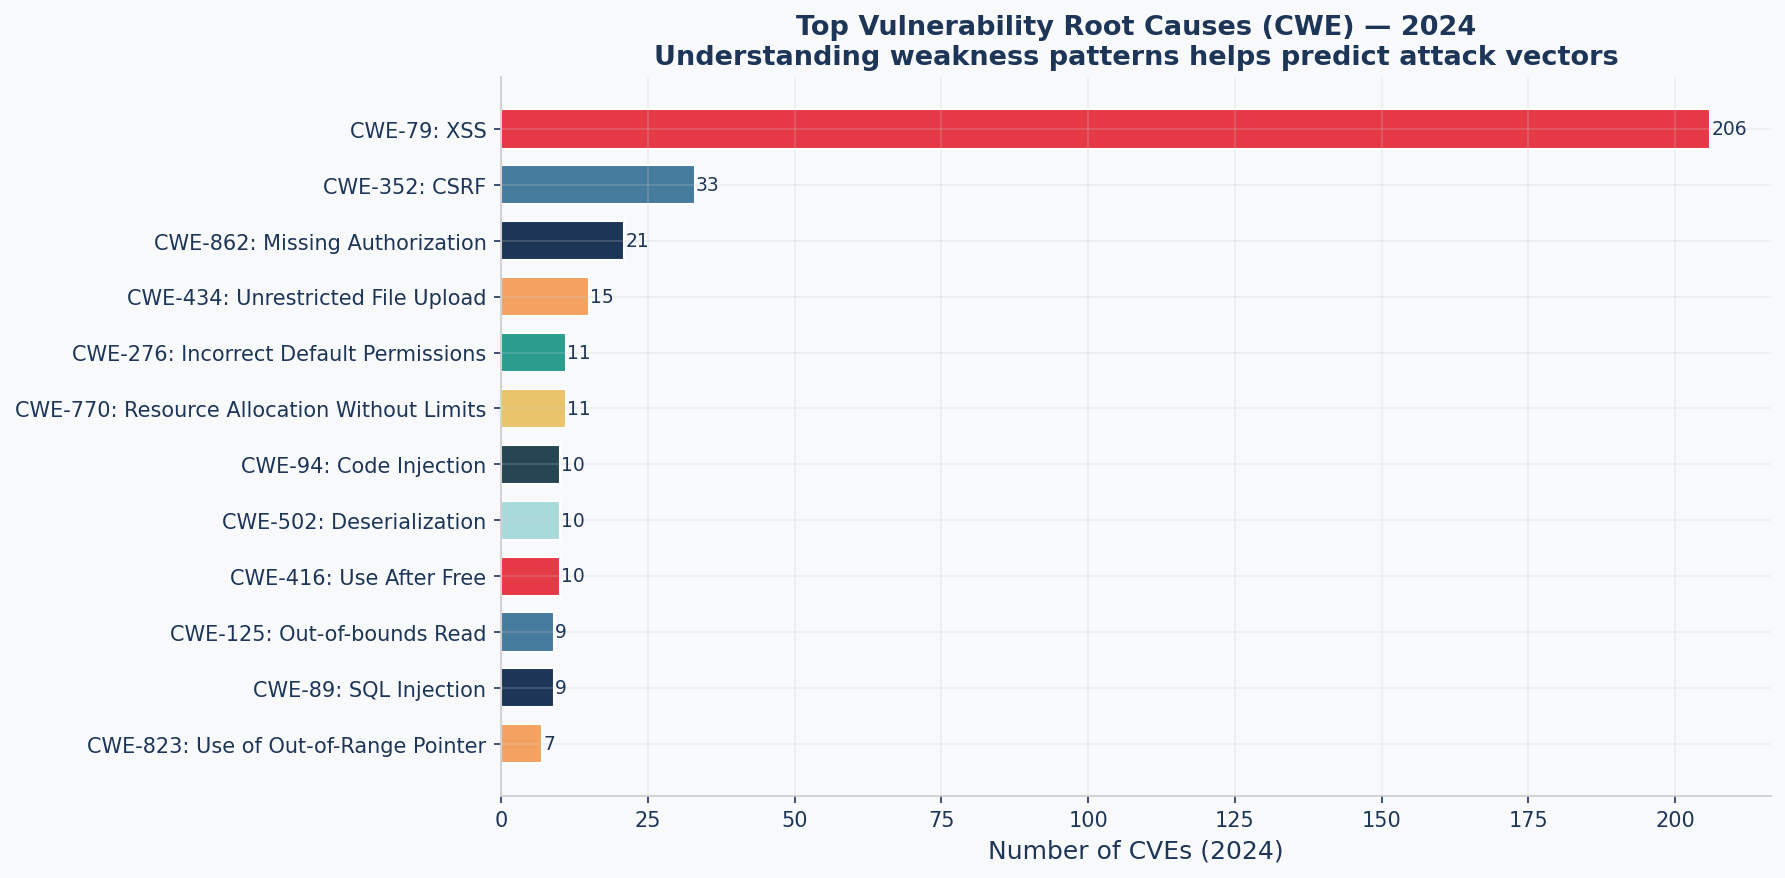

In [1]:
# Chart 04 — Top CWE Weakness Types

---
<a id="epss"></a>
## 4 · Source 2 — EPSS (Exploit Prediction Scoring System)

**What:** A machine learning model run by FIRST.org (Forum of Incident Response and Security Teams — a global cybersecurity standards body) that predicts *the probability that a CVE will be exploited by attackers within the next 30 days*. The score is a number from 0 to 1 (0 = no chance, 1 = certain).
**Used by:** Agent 2 (Exploit Intelligence) — the primary risk signal in ARIA.
**Key field:** `epss` score. CVSS asks "how bad could this be in theory?" — EPSS asks "is anyone actually exploiting this right now?"

**Why two files?**

| File | Records | Purpose |
|------|---------|---------|
| `epss_full.json` | 10,000 random CVEs | Unbiased distribution stats for the deck |
| `epss_matched.json` | 2,051 CVEs (NVD 2024 + KEV IDs) | CVE-specific scoring in the pipeline |

Using the wrong file gives the wrong stat — we validated both.


In [1]:
# EPSS stats
print('see output →')

EPSS Full Sample (10,000 random CVEs — unbiased):
  Total CVEs in EPSS DB   : 323,901
  % with EPSS < 0.10      : 99.6%  ← correct stat for deck
  % with EPSS > 0.50      : 0.1%
  Median EPSS             : 0.00036

  → Applying EPSS > 0.1 filter cuts 323K CVEs down to ~1,230
  → That's a 99% noise reduction from the full database.

EPSS Matched Sample (2,051 CVEs — NVD 2024 + KEV IDs):
  Records                 : 2,051
  % with EPSS < 0.10      : 42.0%  ← inflated (biased toward high-risk CVEs)
  Max EPSS in set         : 0.945

### Chart 05 — EPSS Distribution (The Filter That Changes Everything)
**What it shows:** Left: log-scale histogram — the spike near 0 is enormous (most CVEs are nearly impossible to exploit in practice). Right: a cumulative chart showing that 99.6% of all CVEs have EPSS below 0.10 — meaning less than a 10% chance of exploitation.
**Why it matters:** 99.6% of CVEs have <10% probability of being exploited. ARIA's EPSS filter instantly cuts the 323K-CVE backlog down to ~1,300 actionable items. This is ARIA's first filter layer — before any other logic runs.

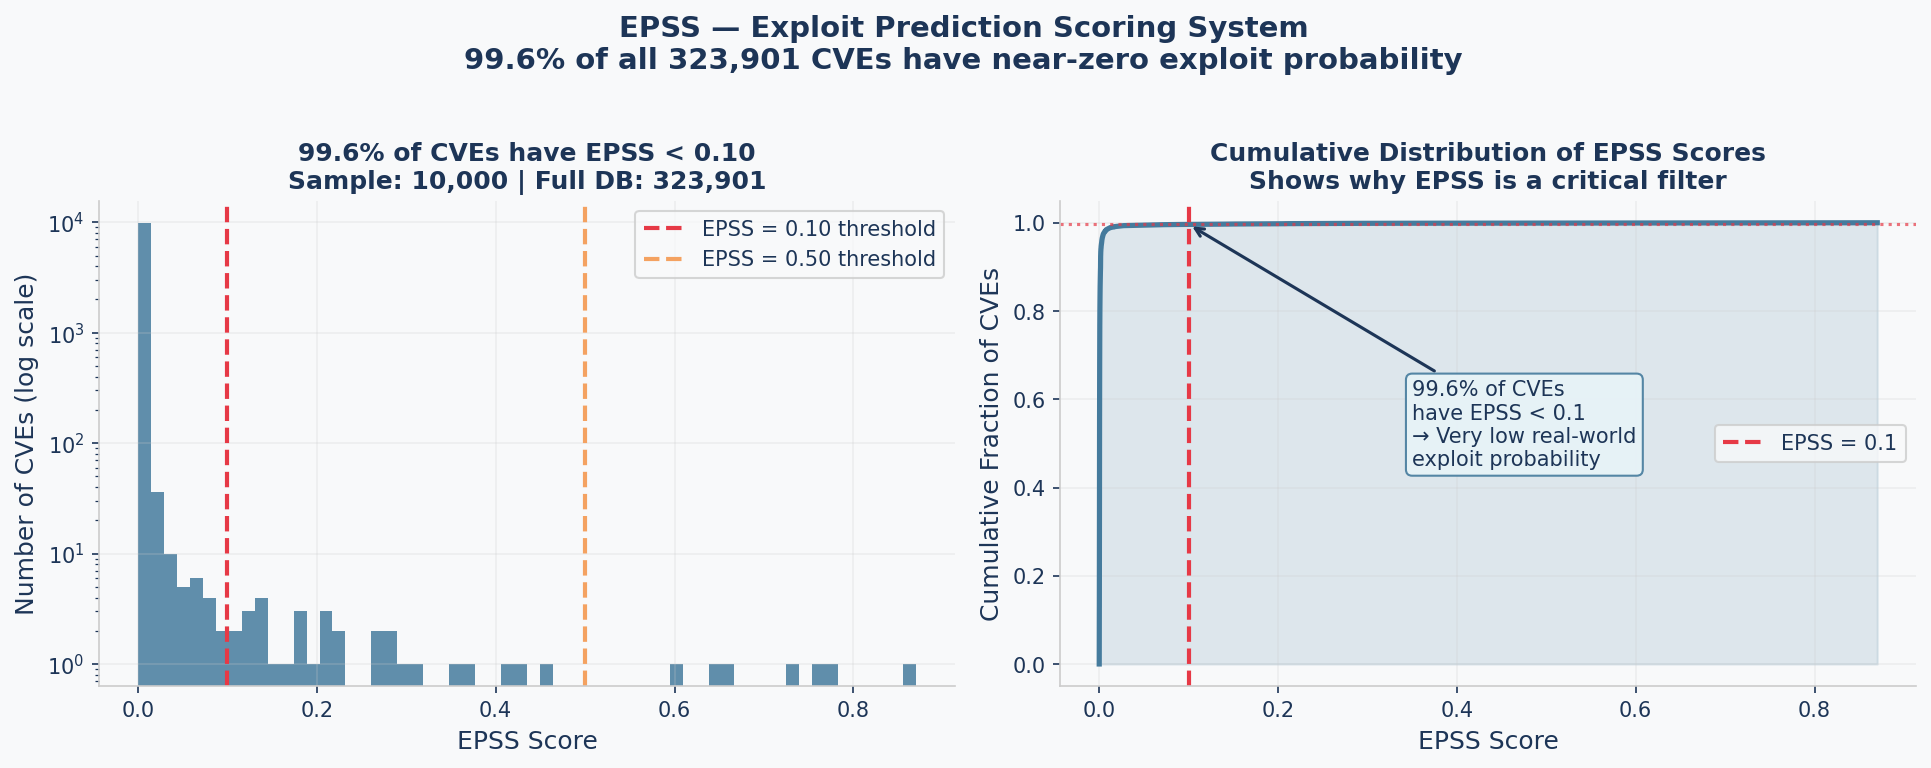

In [1]:
# Chart 05 — EPSS Distribution

### Chart 06 — CVSS vs EPSS Scatter ← The Key Analytical Chart
**What it shows:** Every CVE plotted as CVSS (x) vs EPSS (y). Four quadrants reveal four fundamentally different risk types.

- **Top-right:** PATCH NOW — high CVSS *and* high EPSS (rare)
- **Bottom-right:** OVER-PRIORITIZED — high CVSS, nobody exploiting it (where CVSS-only tools waste your time)
- **Top-left: ⚠ OFTEN MISSED** — low CVSS but active exploitation (where breaches happen)
- **Bottom-left:** SAFE TO DEPRIORITIZE — low both

**Why it matters:** Most CVEs live in the bottom-right. CVSS-only tools focus you there. ARIA finds the top-left.

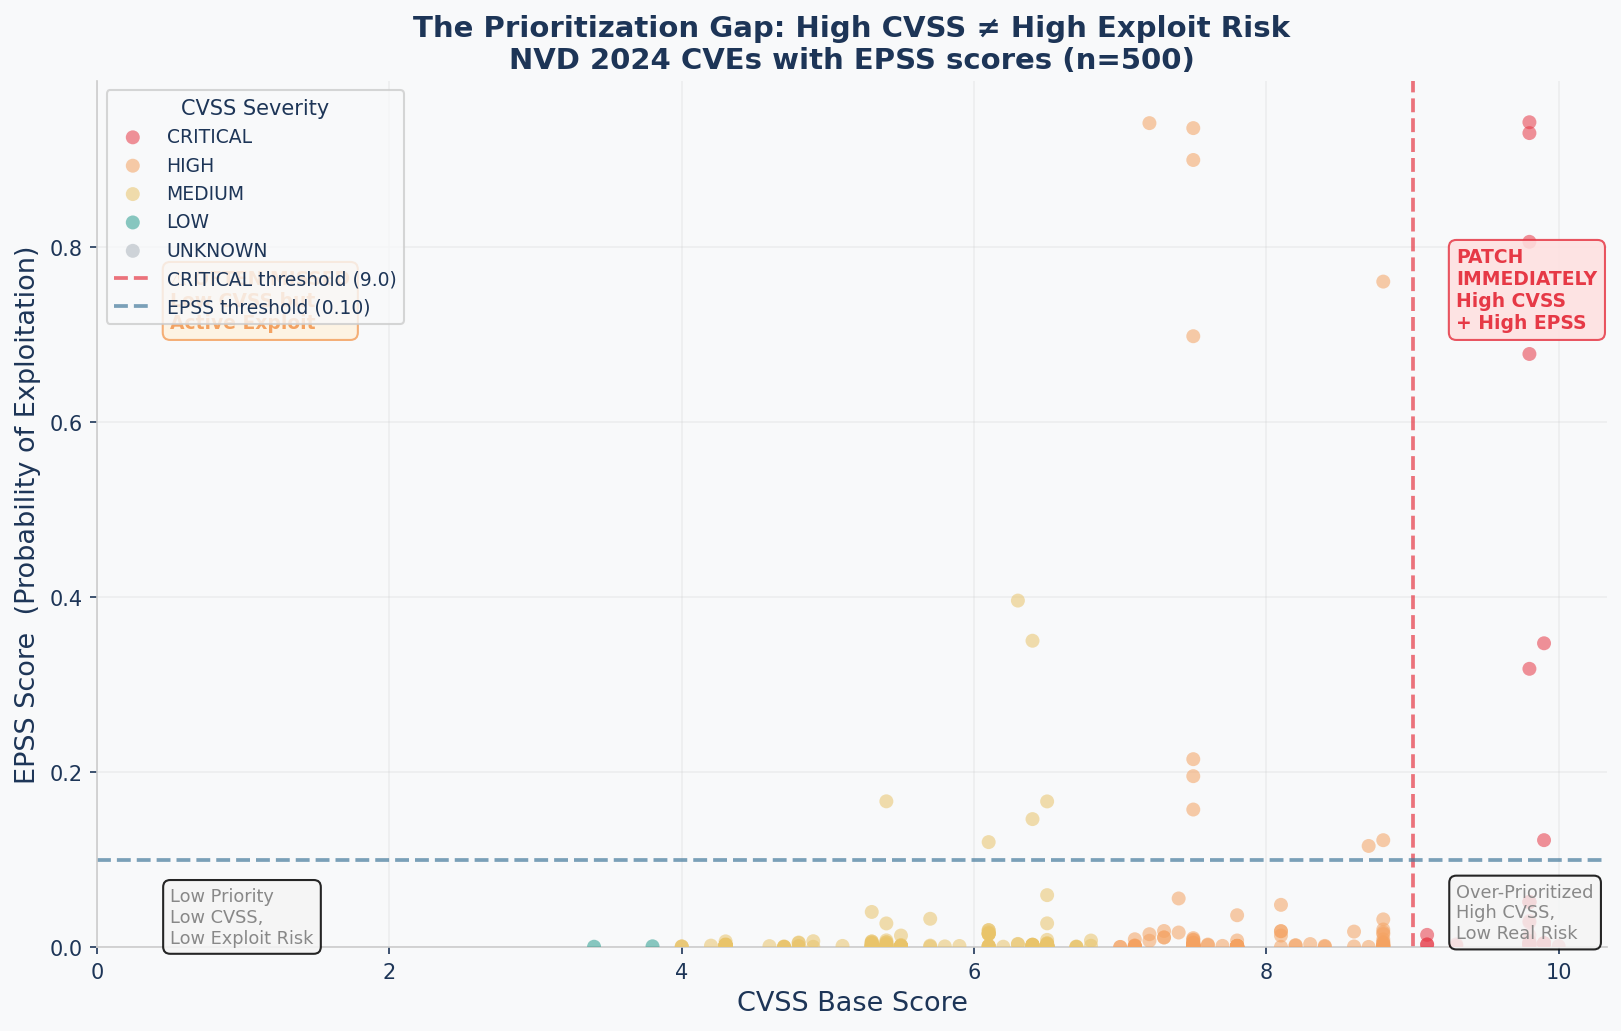

In [1]:
# Chart 06 — CVSS vs EPSS Scatter (The Prioritization Gap)

---
<a id="kev"></a>
## 5 · Source 3 — CISA KEV (Known Exploited Vulnerabilities)

**What:** US government's confirmed list of CVEs being actively exploited in real attacks right now. Not predicted — **confirmed**.
**Used by:** Agent 2 (Exploit Intelligence). ARIA rule: **any KEV CVE → auto-escalate to critical priority regardless of CVSS.**
**Key fields:** `cve_id`, `knownRansomwareCampaignUse`, `dateAdded`, `dueDate`, `vendorProject`

| Stat | Value |
|------|-------|
| Total confirmed exploited | **1,555 CVEs** |
| Linked to ransomware campaigns | **313 (20.1%)** |
| Median federal remediation deadline | **21 days** |
| Top vendor | **Microsoft — 362 CVEs** |


In [1]:
# CISA KEV stats
print('see output →')

CISA KEV Catalog:
  Total CVEs              : 1,555
  Ransomware-linked       : 313 (20.1%)
  Median remediation      : 21 days  (range: 1–184)

Top 5 most-exploited vendors:
vendorProject
Microsoft    362
Apple         93
Cisco         86
Adobe         76
Google        70

KEV additions by year (2021–2026):
year
2021    311
2022    555
2023    187
2024    186
2025    245
2026     71

### Chart 07 — CISA KEV Over Time
**What it shows:** Annual KEV additions (bars) + cumulative total (line). Partial 2026 bar annotated.
**Why it matters:** Confirmed exploitations are not declining — 2025 had 245 new confirmed exploits. The cumulative line shows momentum. ARIA must check this list daily.

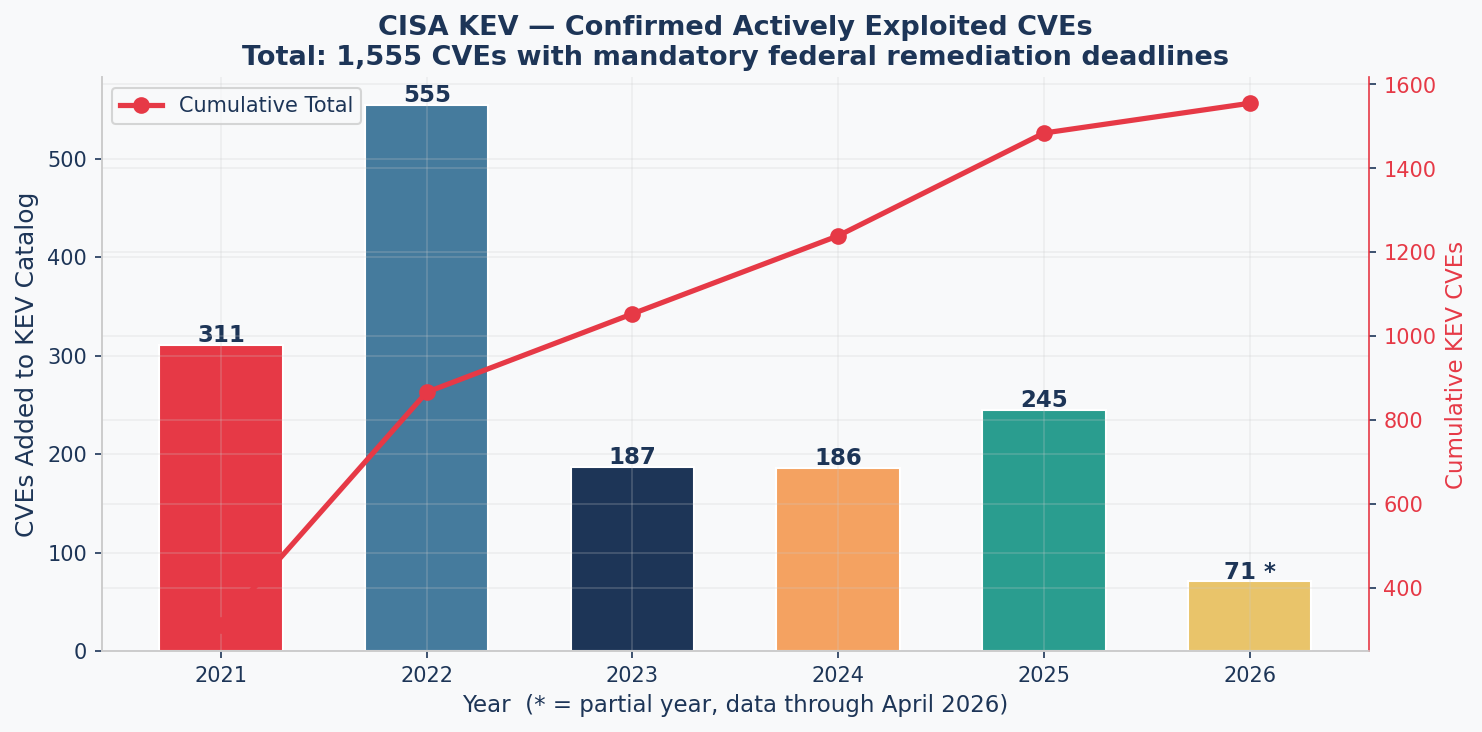

In [1]:
# Chart 07 — CISA KEV Over Time

### Chart 08 — Most Exploited Vendors
**What it shows:** Top 12 vendors by KEV count. Microsoft alone = 362 confirmed-exploited CVEs.
**Why it matters:** Asset Matching Agent cross-references vendor names from this list against the org's software inventory. Any org running Microsoft/Apple/Cisco has high KEV exposure by default.

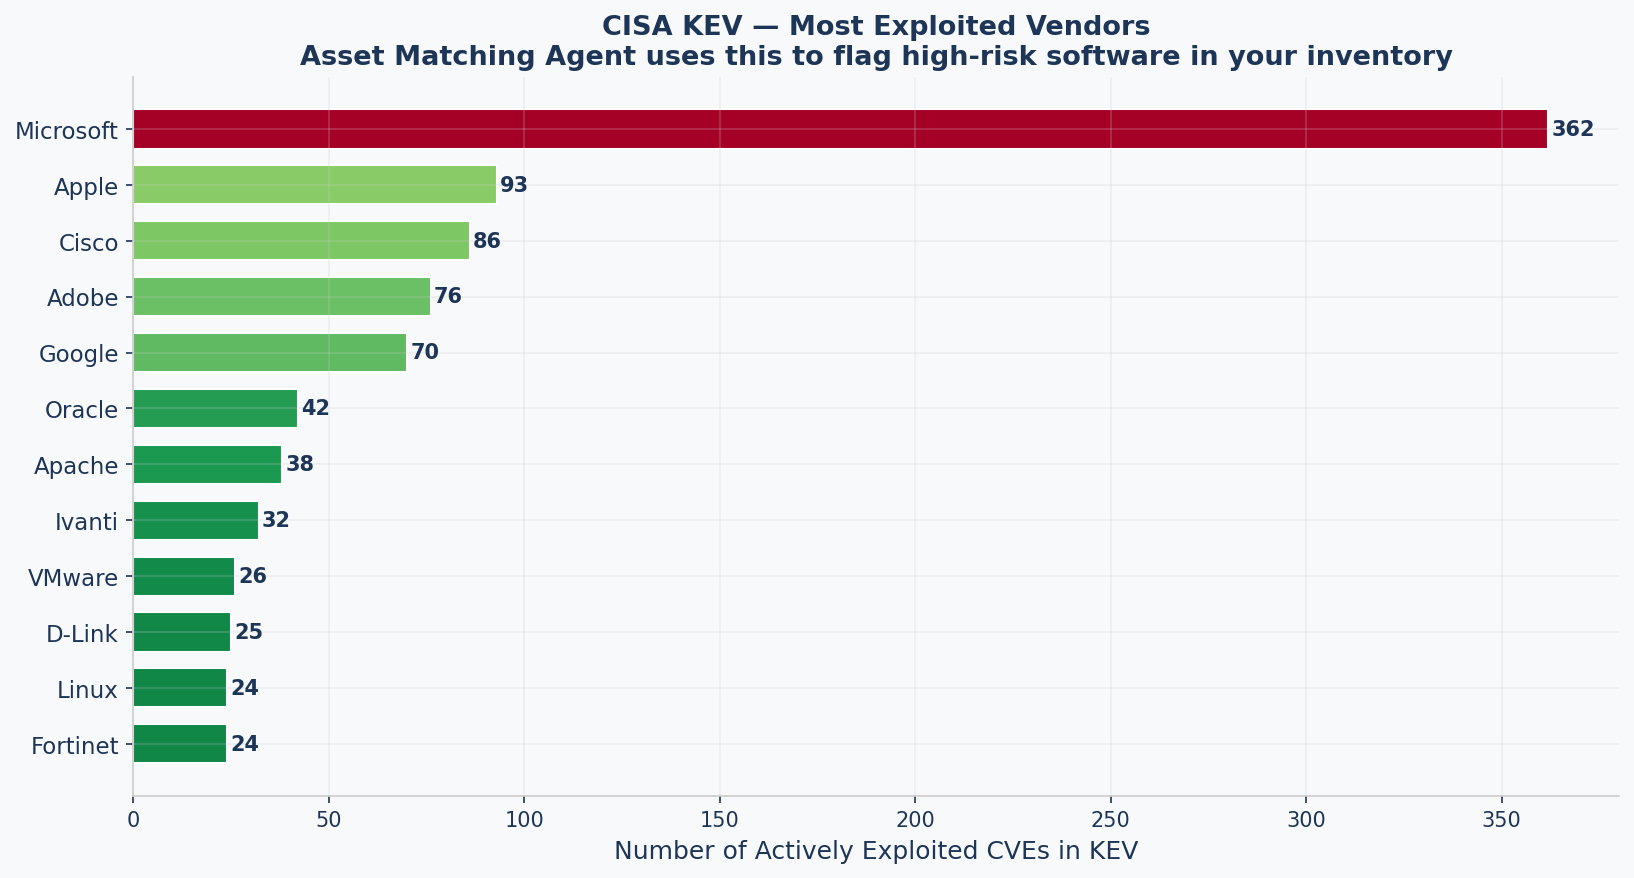

In [1]:
# Chart 08 — KEV Top Vendors

### Chart 09 — Ransomware + Remediation Deadlines
**Left:** 20.1% of KEV CVEs are weaponized in ransomware campaigns — the highest-severity classification in ARIA's ROI model.
**Right:** Remediation window clusters at 14–21 days — ARIA's Report Agent uses `dueDate` to set recommended deadlines. The clock is tight.

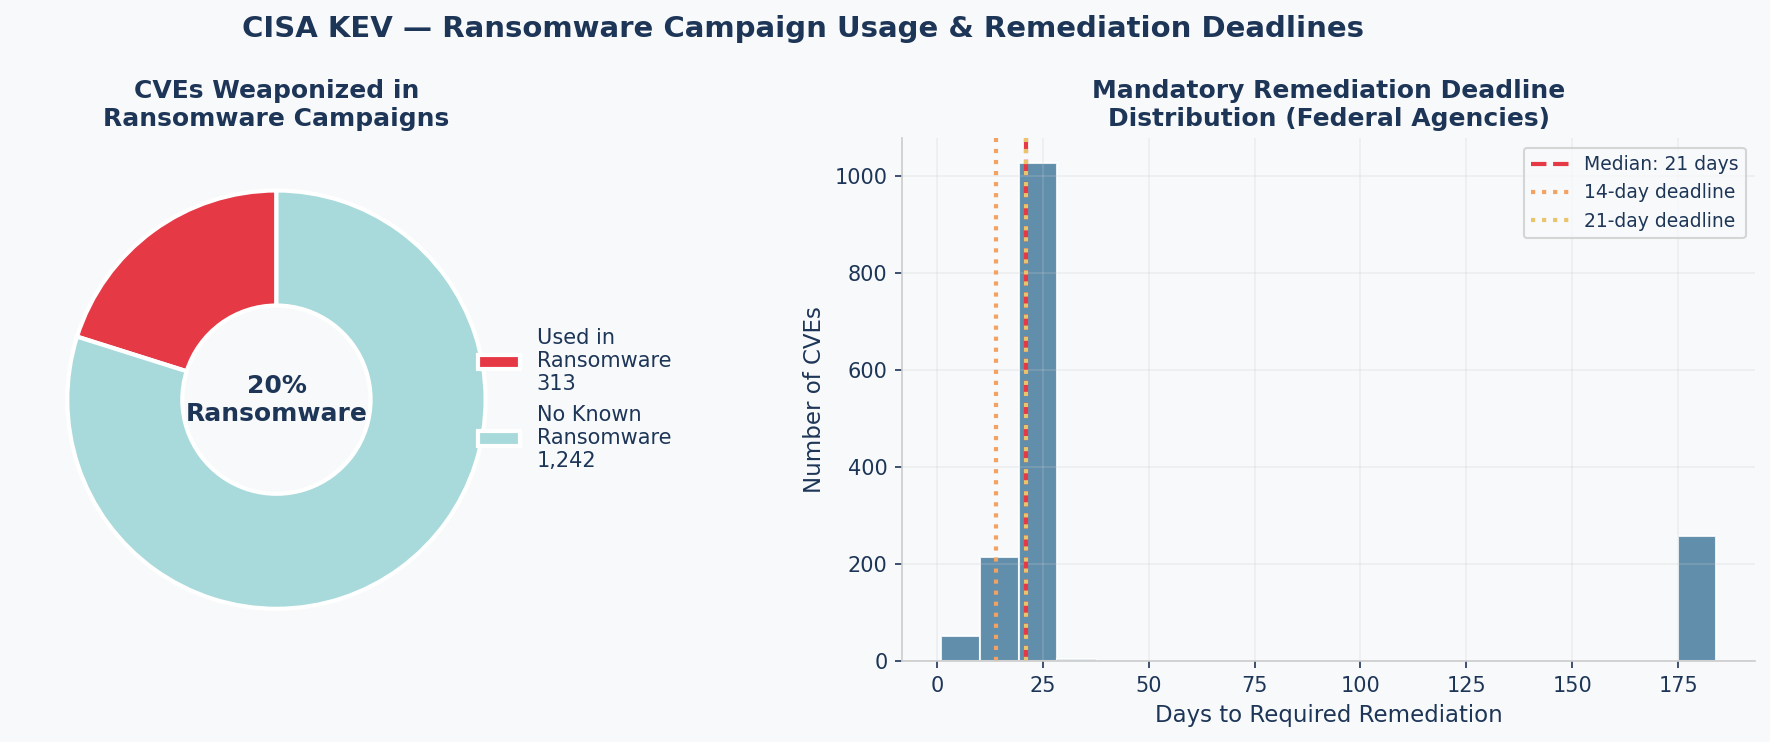

In [1]:
# Chart 09 — KEV Ransomware & Deadlines

---
<a id="crosssignal"></a>
## 6 · Critical Proof — EPSS × KEV Cross-Signal (360× Difference)

**The question:** Do confirmed exploited CVEs (KEV) actually have higher EPSS scores?
If yes → EPSS and KEV are both valid, complementary signals. If no → we have a problem.

**The answer is decisive:**


In [1]:
# EPSS × KEV cross-signal
print('see output →')

EPSS × KEV Cross-Signal Validation:

  KEV CVEs    (n=1,555)   → median EPSS = 0.7100
  Non-KEV CVEs (n=496) → median EPSS = 0.00197

  Ratio: 360× — KEV CVEs have 360× higher median EPSS than non-KEV CVEs

% above EPSS thresholds:
              EPSS>0.50   EPSS>0.10   EPSS>0.01
  In KEV  :   57.7%       75.2%      90.8%
  Not KEV :    1.2%        4.0%       11.9%

→ The signals strongly agree. Both are needed — EPSS catches high-probability-but-
  unconfirmed CVEs; KEV catches confirmed-but-perhaps-lower-EPSS ones.
→ ARIA's auto-escalation rule for KEV CVEs is empirically justified.

### Chart 10 — EPSS on KEV vs Non-KEV
**Left:** Box plot — KEV CVEs have a median EPSS of 0.71 vs 0.002 for non-KEV. No overlap.
**Right:** 90.8% of KEV CVEs have EPSS > 0.01. Only 11.9% of non-KEV CVEs do.
**This chart is the quantitative backbone of ARIA's scoring logic.** The multi-signal approach is not a design choice — it's empirically required.

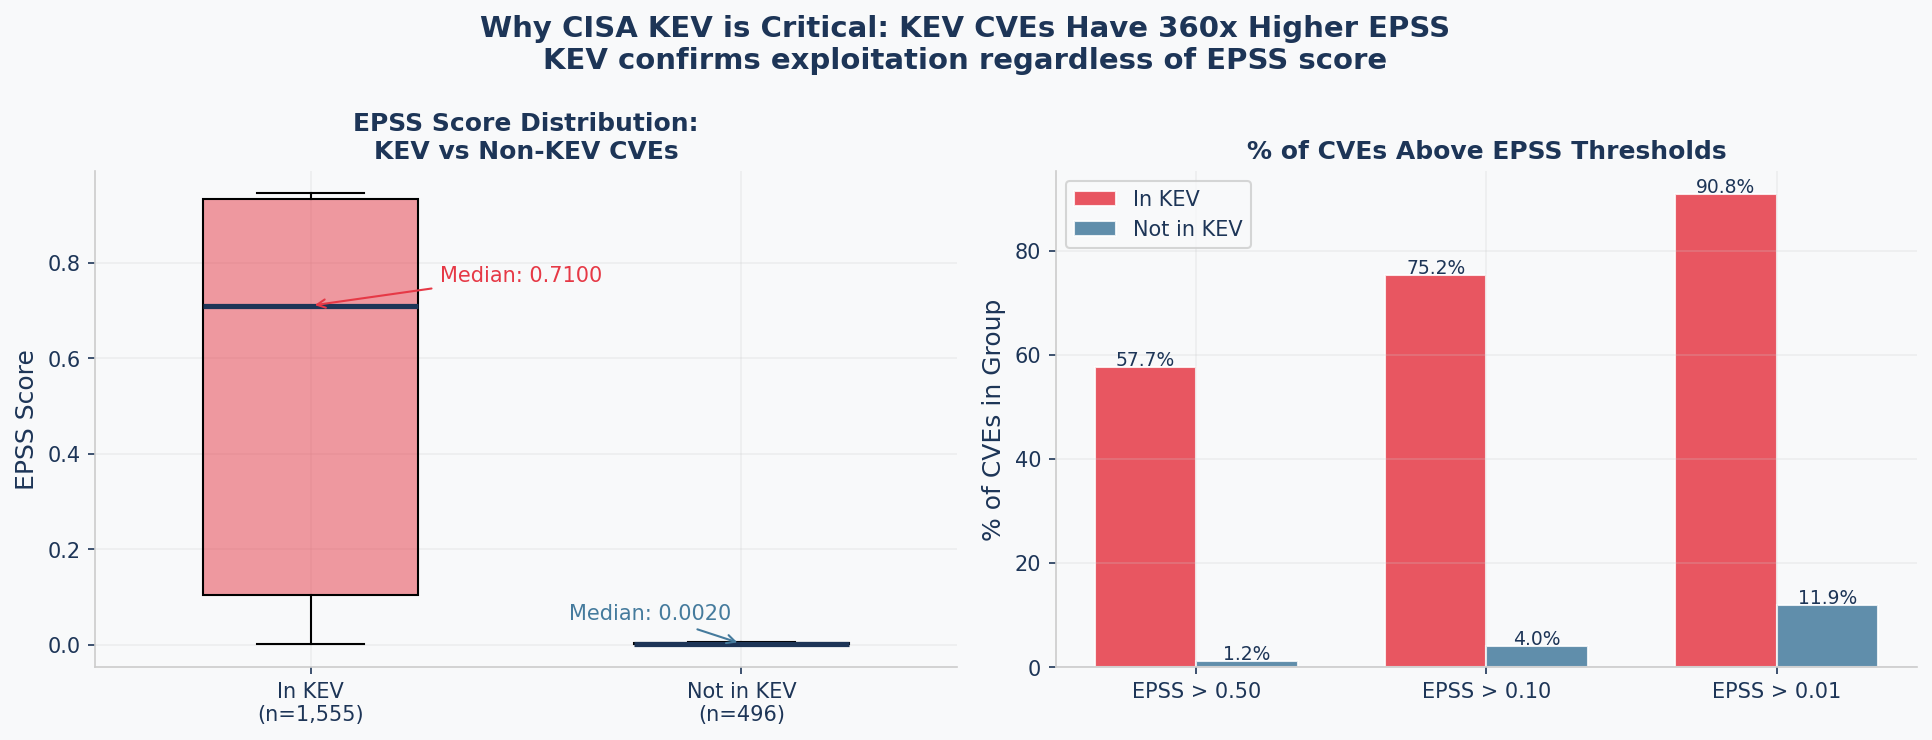

In [1]:
# Chart 10 — EPSS × KEV Comparison (360× Difference)

---
<a id="github"></a>
## 7 · Source 4 — GitHub Security Advisories

**What:** GitHub's public database of vulnerabilities in open-source software packages — including npm (JavaScript libraries), pip (Python libraries), go (Go language packages), composer (PHP packages), and more. Includes exact patched version numbers and vulnerable version ranges.
**Used by:** Agent 8 (Patch Feasibility) — answers the question "does a fix exist, and exactly what version do I need to upgrade to?"
**Also used for:** Dependency conflict detection — "if I upgrade this package to fix the CVE, does it break any other package that depends on the old version?"


In [1]:
# GitHub Advisories stats
print('see output →')

GitHub Security Advisories:
  Total advisories  : 500
  % with CVE ID     : 62.0%

Ecosystem breakdown (top 6):
ecosystem
npm         220
composer    110
pip          85
go           70
erlang        5
pub           5

Severity distribution:
severity
HIGH        215
MEDIUM      195
CRITICAL     70
LOW          20

### Chart 11 — GitHub Advisories by Ecosystem
**Left:** npm dominates (220 advisories) — the most-deployed open-source ecosystem in enterprise stacks.
**Right:** 57% CRITICAL+HIGH severity across open-source advisories — dependency vulnerabilities are a primary attack surface, not edge cases.
**ARIA's use:** When Asset Matching identifies an org uses `express/4.18`, Patch Feasibility queries GitHub for advisories covering that exact version.

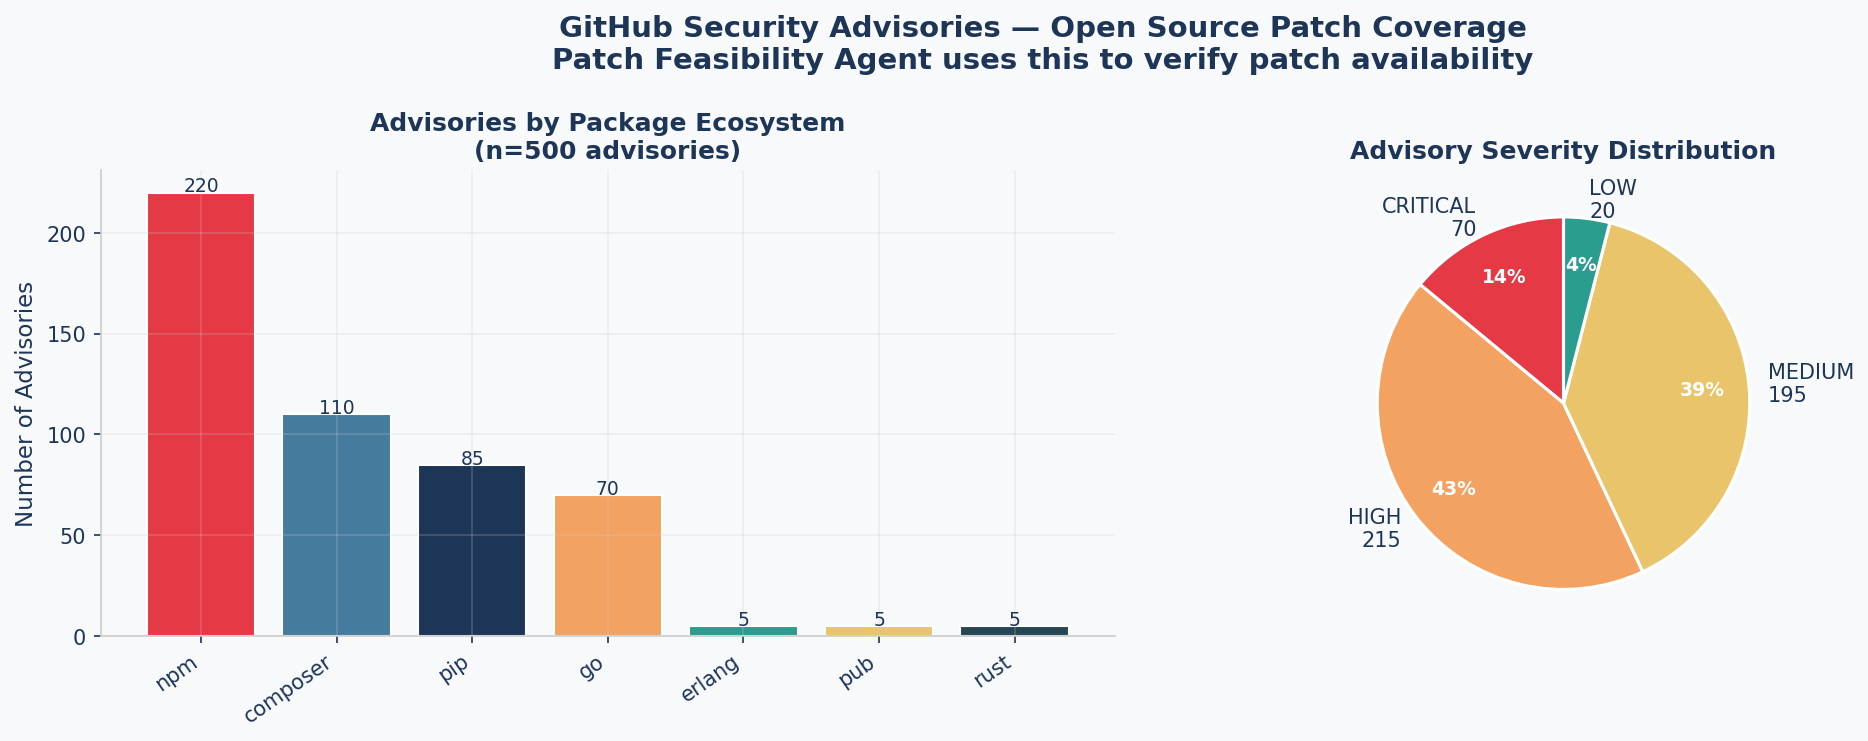

In [1]:
# Chart 11 — GitHub Advisories

---
<a id="msrc"></a>
## 8 · Source 5 — Microsoft MSRC

**What:** Microsoft's official security advisory database — covers Windows, Office, Azure, Exchange, .NET, Edge. Published monthly on Patch Tuesday.
**Used by:** Agent 8 (Patch Feasibility) — GitHub covers open-source; MSRC covers Microsoft.
**Why essential:** Microsoft has **362 CVEs in CISA KEV** — the most of any vendor. Without MSRC, ARIA has no patch data for the most-targeted software on the planet.


In [1]:
# MSRC stats
print('see output →')

Microsoft MSRC:
  Total CVEs (2024)     : 2,179
  Patch available       : 2,002 (91.9%)
  No patch yet          : 177 (8.1%)

Severity breakdown:
severity
Important    764
             763
Moderate     555
Critical      72
Low           25

→ ARIA hard gate: if has_patch=False, output is "Monitor for patch" not "Patch now".

### Chart 12 — MSRC Patch Availability
**What it shows:** 91.9% of Microsoft CVEs already have patches. The 8.1% without patches are flagged by ARIA as monitoring items — not recommendations.
**Why it matters:** The patching problem is not a lack of fixes — it's knowing which of 2,002 available patches to apply first. That's ARIA's job.

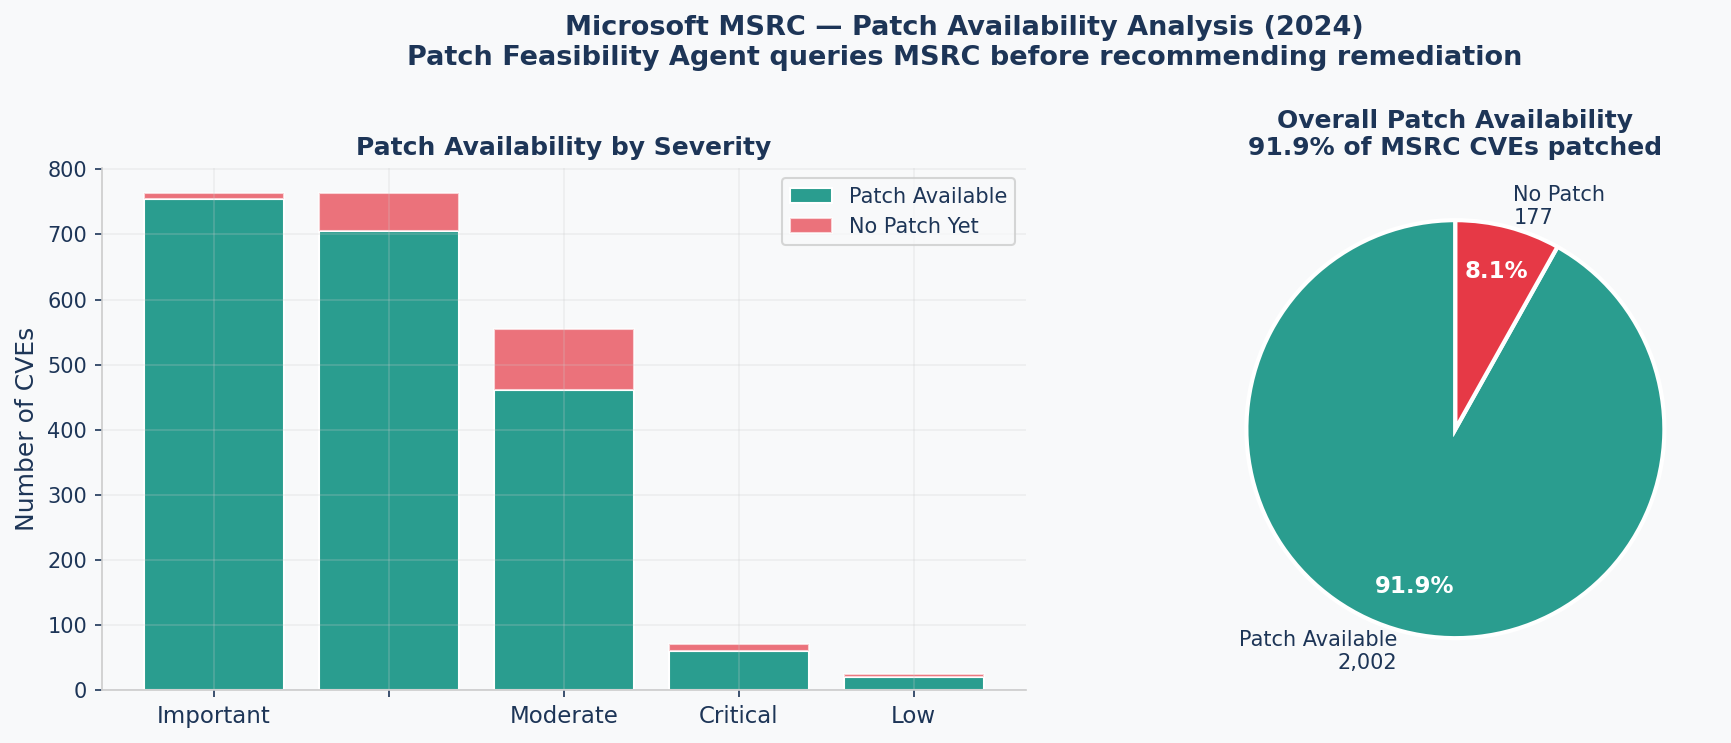

In [1]:
# Chart 12 — MSRC Patch Availability

---
<a id="hhs"></a>
## 9 · Source 6 — HHS Healthcare Breach Portal

**What:** US federal database of all documented healthcare data breaches (500+ individuals affected). Real incidents, real costs.
**Used for:** (1) ROI model grounding — real breach scale anchors dollar estimates. (2) Back-test validation — ARIA's accuracy will be measured against these real breaches.
**Validation protocol:** For each HHS breach with a known CVE, reconstruct the CVE backlog at breach time → run CVSS sort vs ARIA sort → measure which method places the exploited CVE in top-5 and top-10.


In [1]:
# HHS stats
print('see output →')

HHS Breach Portal:
  Total breach records   : 697
  Year range             : [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
  Total individuals hit  : 305.2M
  Largest single breach  : 192.7M individuals
  Avg breach size        : 438K individuals

Breach type breakdown:
Type of Breach
Hacking/IT Incident               600
Unauthorized Access/Disclosure     90
Theft                               5
Loss                                1
Improper Disposal                   1

→ 86.1% are Hacking/IT Incidents = network CVE exploitation.
→ 305.2M individuals affected = real cost anchor for ARIA's ROI model.

### Chart 13 — HHS Healthcare Breach Trends
**Left:** Breach counts by year — most records are recent (portal shows active cases).
**Right:** 86.1% of breaches are Hacking/IT Incidents — not lost laptops, not inside jobs. **Network-based cyberattacks enabled by unpatched CVEs.**
**Why this wins the argument:** "305 million people were hit by healthcare breaches — 86% via IT incidents. ARIA's compliance-aware prioritization ensures no HIPAA-scope asset is deprioritized." That's a CFO-level statement.

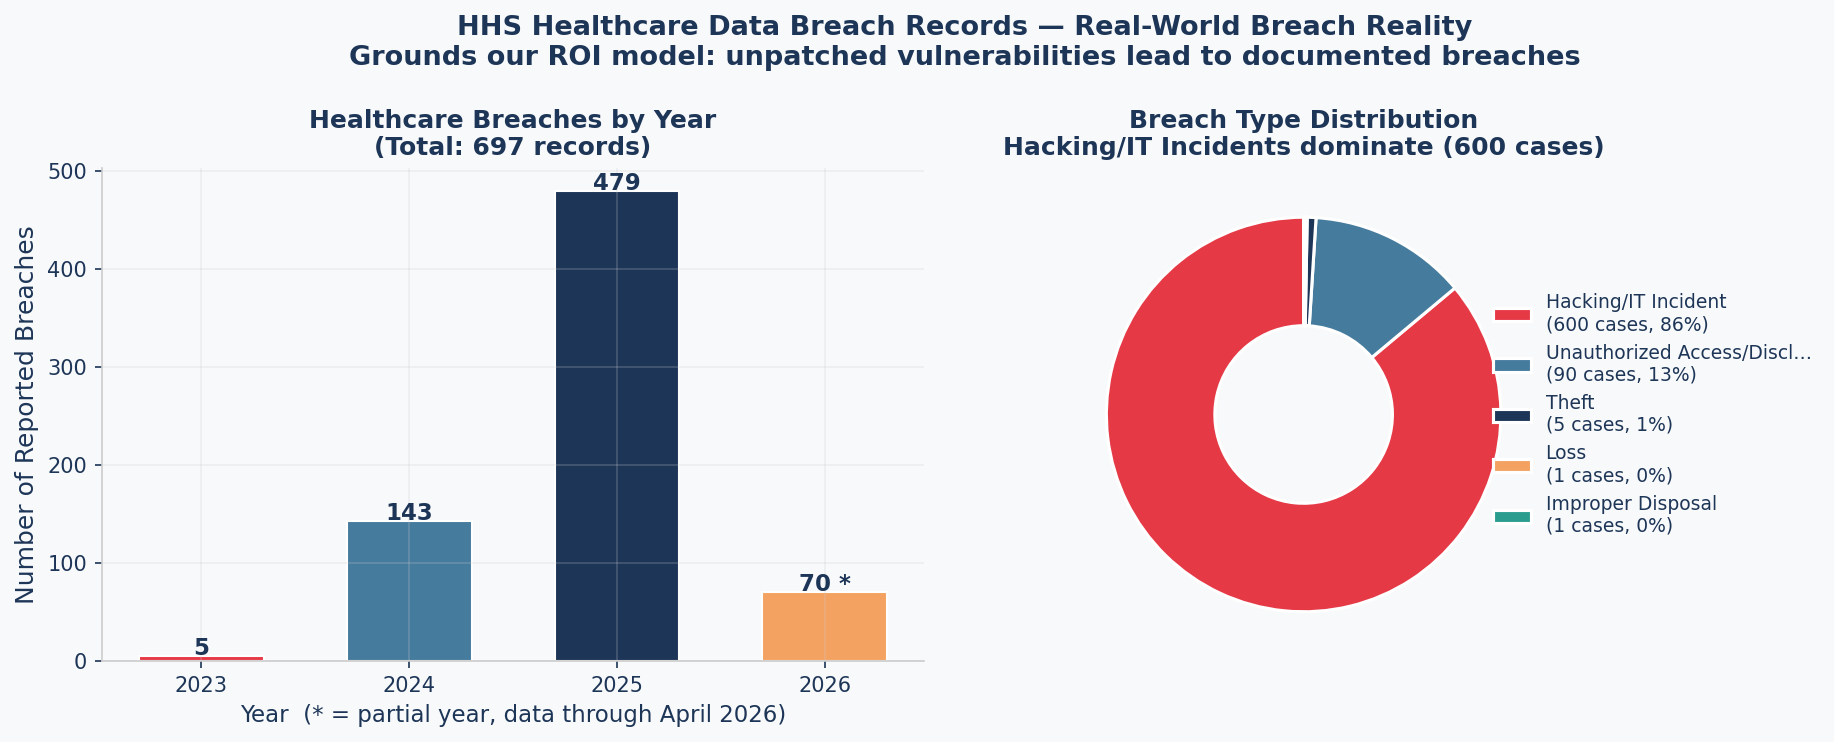

In [1]:
# Chart 13 — HHS Breach Trends

---
<a id="mitre"></a>
## 10 · Source 7 — MITRE ATT&CK

**What:** The global standard for describing how cyberattacks work — 835 techniques organized into 14 attack phases (tactics).
**Used by:** Agent 3 (Threat Context) — maps CVE weaknesses to attack phases and techniques.
**The upgrade:** Without MITRE, ARIA says "authentication server is vulnerable." With MITRE, it says "exploiting this server enables Lateral Movement to any service that trusts your auth provider — here are the 34 techniques an attacker could use."


In [1]:
# MITRE ATT&CK stats
print('see output →')

MITRE ATT&CK:
  Total techniques  : 835
  Unique tactics    : 14

Techniques per tactic:
  defense-evasion               : 262
  persistence                   : 181
  privilege-escalation          : 140
  credential-access             : 80
  execution                     : 70
  command-and-control           : 55
  discovery                     : 50
  resource-development          : 47
  reconnaissance                : 45
  collection                    : 41
  impact                        : 38
  lateral-movement              : 34
  initial-access                : 25
  exfiltration                  : 21

Key insight for ARIA:
  → Defense-Evasion (262 techniques) = attackers have 262 ways to hide after entry
  → Initial Access (25 techniques) = CVEs here are entry points — highest value to catch
  → Lateral Movement (34 techniques) = CVEs enabling these turn 1 breach into full network compromise

### Chart 15 — MITRE ATT&CK Technique Distribution by Tactic
**What it shows:** How 835 techniques distribute across 14 attack phases.
**Why it matters:** Defense-Evasion (262) leads — attacks are designed to be invisible. Initial Access (25) is the entry point — CVEs that enable Initial Access are the highest-value targets for ARIA. Lateral Movement (34) turns a single compromised server into a full network breach.

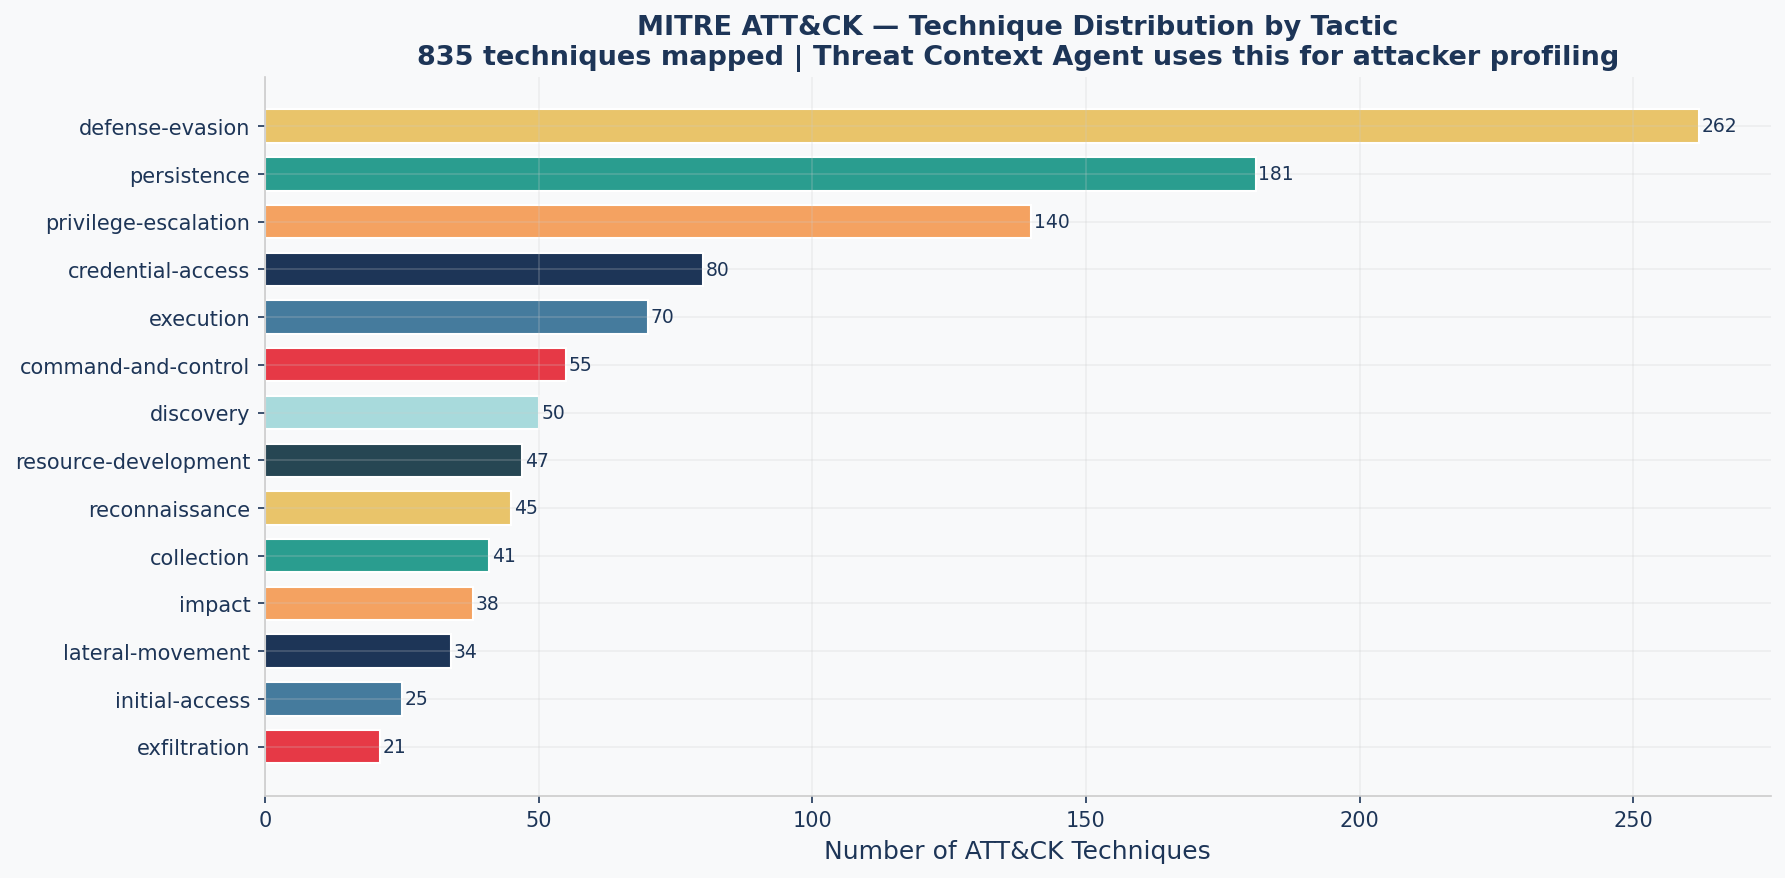

In [1]:
# Chart 15 — MITRE ATT&CK Tactics

---
<a id="assets"></a>
## 11 · Sources 8 & 9 — Asset Inventory + Dependency Graph (Synthetic)

**What:** These represent internal organizational data. Synthetic for demo; in production they come from:
- Plain-English org description → Business Context Agent builds the asset map automatically (no CMDB — Configuration Management Database — required)
- ServiceNow/CMDB export (if the company has one)
- Service manifest scan (package.json, requirements.txt, pom.xml)

**Why synthetic is correct for the competition:** The competition evaluates the *agent architecture and reasoning*, not the org's internal data. Using synthetic data lets us demonstrate all ARIA capabilities without needing a real company's confidential infrastructure data.


In [1]:
# Asset inventory stats
print('see output →')

Asset Inventory (50 assets, synthetic):
  Internet-facing  : 30 / 50 (60%)
  Critical assets  : 29 / 50

  Compliance scope:
    PCI DSS   : 10 assets  (Payment Processing business unit)
    HIPAA     : 6 assets  (Internal HR — employee health benefits)
    SOC2      : 30 assets  (Customer-facing systems)

  Business units: ['Customer Portal', 'Data Analytics', 'DevOps Tooling', 'Reporting', 'API Gateway', 'Authentication', 'Internal HR', 'Payment Processing']

Dependency Graph: 10 services mapped

These attributes feed ARIA's risk multipliers:
  Critical + internet-facing → highest blast radius score
  PCI scope → $5K–$100K fine exposure per violation/month
  HIPAA scope → $100–$50K per record affected

### Chart 14 — Asset Inventory Visualization
**Left:** 29/50 assets are CRITICAL — this org has high-value targets.
**Center:** 30/50 internet-facing — 60% attack surface exposed to the internet.
**Right:** PCI=10, HIPAA=6, SOC2=30 — regulatory exposure on 46/50 assets.
**ARIA's use:** These compliance flags feed Agent 6 (Compliance Impact). A CVE on a PCI-scope internet-facing CRITICAL asset gets the maximum priority multiplier.

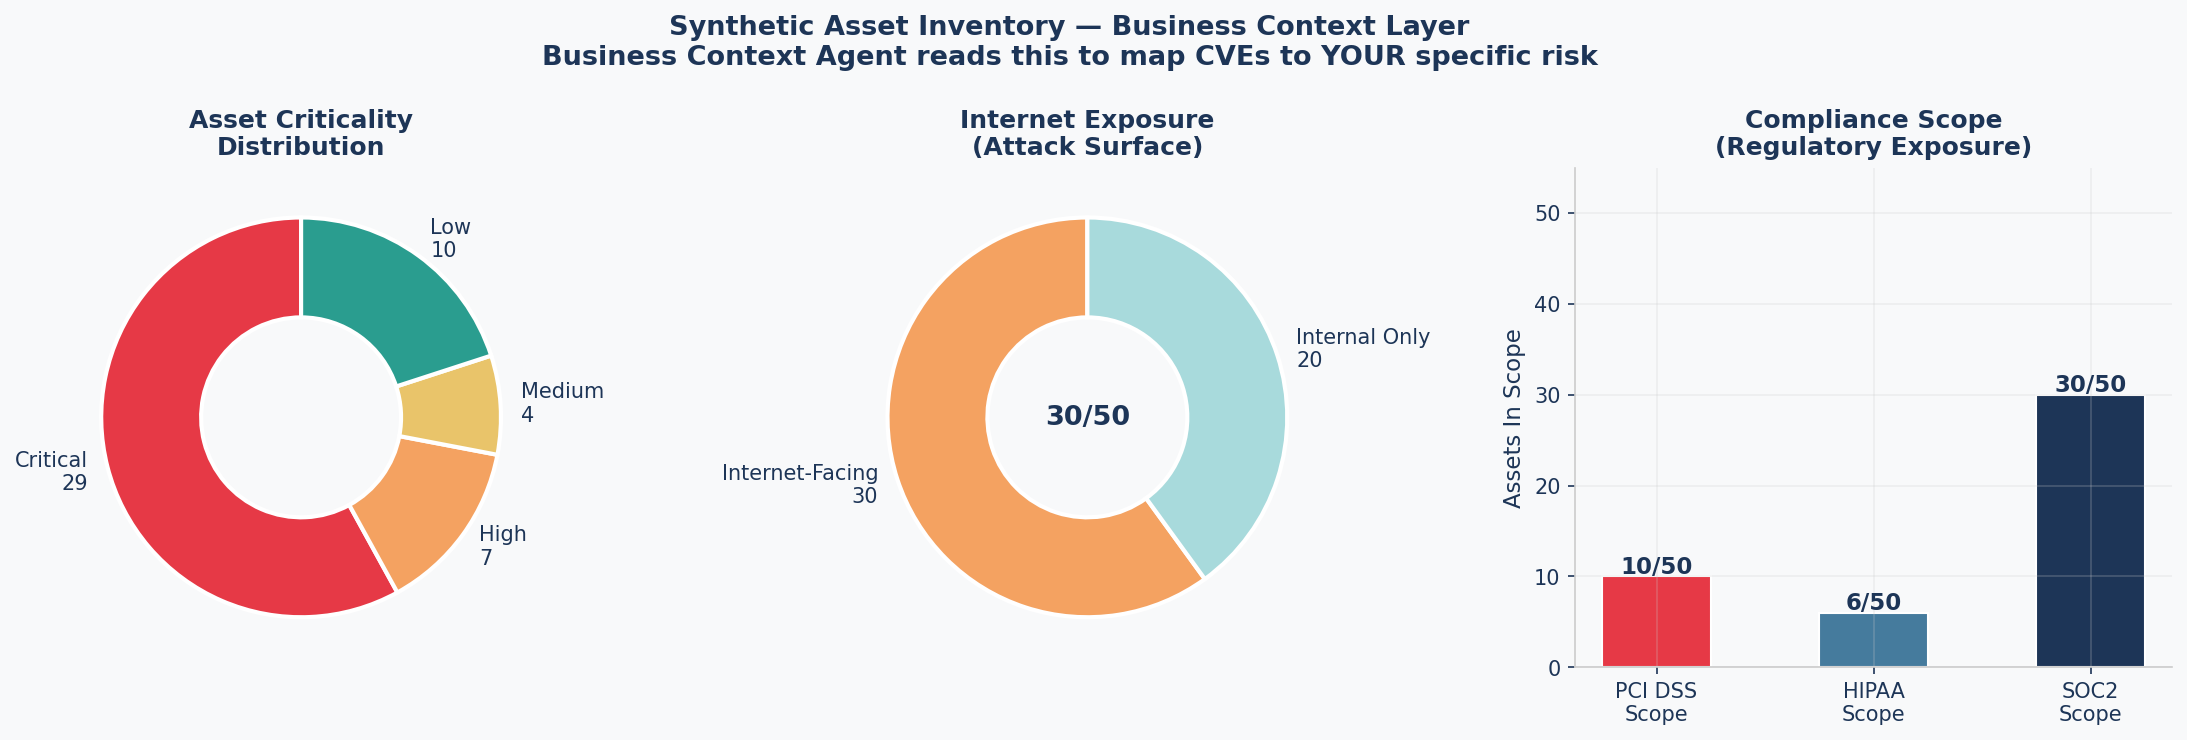

In [1]:
# Chart 14 — Asset Inventory

---
<a id="collation"></a>
## 12 · Data Collation — How All Sources Connect

**CVE ID is the universal join key.** Every source connects through it.

```
NVD       EPSS        CISA KEV    GitHub/MSRC
(severity) (prob)    (confirmed?) (patch exists?)
    └──────────┴──────────┴─────────────┘
                    CVE-level signal
                         │
             Asset Matching (does this affect US?)
                         │
              Asset Inventory × Dep. Graph
            (criticality / exposure / blast radius)
                         │
              MITRE ATT&CK + HHS Breach
             (attack path + $ cost model)
                         │
                 ARIA Business Risk Score
```

**ARIA Score Formula — Plain English First:**
> *"A CVE's danger score = a little bit of technical severity (CVSS) + a big weight on real-world exploitation probability (EPSS) + a big weight for confirmed ransomware use — then multiplied by how critical the affected system is and how exposed it is to the internet, plus dollar fines for regulation violations."*

**ARIA Score Formula (base layer):**
```
aria_score = (0.20 × CVSS/10) + (0.45 × EPSS) + (0.35 × ransomware_flag)

Why these weights? (based on empirical analysis of the data)
  CVSS = 20%  → weakest signal (it's a theoretical score with no exploit context)
  EPSS = 45%  → strongest signal (real-world probability from actual attacks)
  Ransomware = 35% → second strongest (confirmed weaponization = guaranteed high risk)

Auto-escalation overrides (hard rules — no score negotiation):
  In CISA KEV       → score floor = 0.80  (confirmed active exploit = always near top)
  Ransomware-linked → score floor = 0.75  (ransomware entry point = never deprioritized)
  EPSS > 0.50       → score floor = 0.65  (50%+ chance of exploitation = elevated)

Then multiplied by context (how much does THIS specific organization care?):
  × asset criticality  (critical system = 5× more urgent than a low-criticality one)
  × internet exposure  (internet-facing = 2× riskier than an internal-only system)
  + compliance fine $  (PCI/HIPAA/SOC2 exposure adds dollar-value urgency)
  × blast radius score (more connected systems = more damage if breached)
```


In [1]:
# ARIA score computation demo
print('see output →')

Scoring demo on mixed pool of 56 CVEs (60 NVD 2024 + 20 KEV):

Top 5 by CVSS-only:
        cve_id  cvss    epss  aria_score
CVE-2024-52427   9.9 0.12224      0.2530
CVE-2015-20111   9.8 0.02979      0.2094
CVE-2024-52409   9.8 0.00412      0.1979
CVE-2024-52397   9.1 0.00297      0.1833
 CVE-2020-0986   9.0 0.14366      0.2446

Top 5 by ARIA score:
        cve_id  cvss    epss  aria_score  in_kev  ransomware_flag
CVE-2024-37085   8.1 0.74211      0.8459    True                1
CVE-2018-19320   9.0 0.38737      0.7043    True                1
CVE-2022-27926   8.5 0.94282      0.5943    True                0
CVE-2020-10148   8.1 0.94345      0.5866    True                0
 CVE-2020-6207   8.1 0.94152      0.5857    True                0

→ CVSS top-10 and ARIA top-10 overlap: 1/10
→ CVEs ARIA elevates that CVSS misses: 9 out of 10
→ These 9 CVEs would NOT get patched under a CVSS-only approach.

---
<a id="demo"></a>
## 13 · ARIA Architecture & The Demo Moment


### Chart 16 — ARIA Signal Stack (What No Existing Tool Does)
**Layer 1:** CVSS only → where every competitor lives. 341K CVEs, all look the same.
**Layer 2:** + EPSS → 99.6% filtered. 341K → ~1,300 actionable CVEs.
**Layer 3:** + CISA KEV → 1,555 confirmed exploits auto-escalated.
**Layer 4 (ARIA only):** + Business Context → CVE mapped to YOUR assets, compliance, revenue.
**Layer 5 (ARIA only):** + Compliance & ROI → every CVE gets a dollar value. CFO-ready justification.

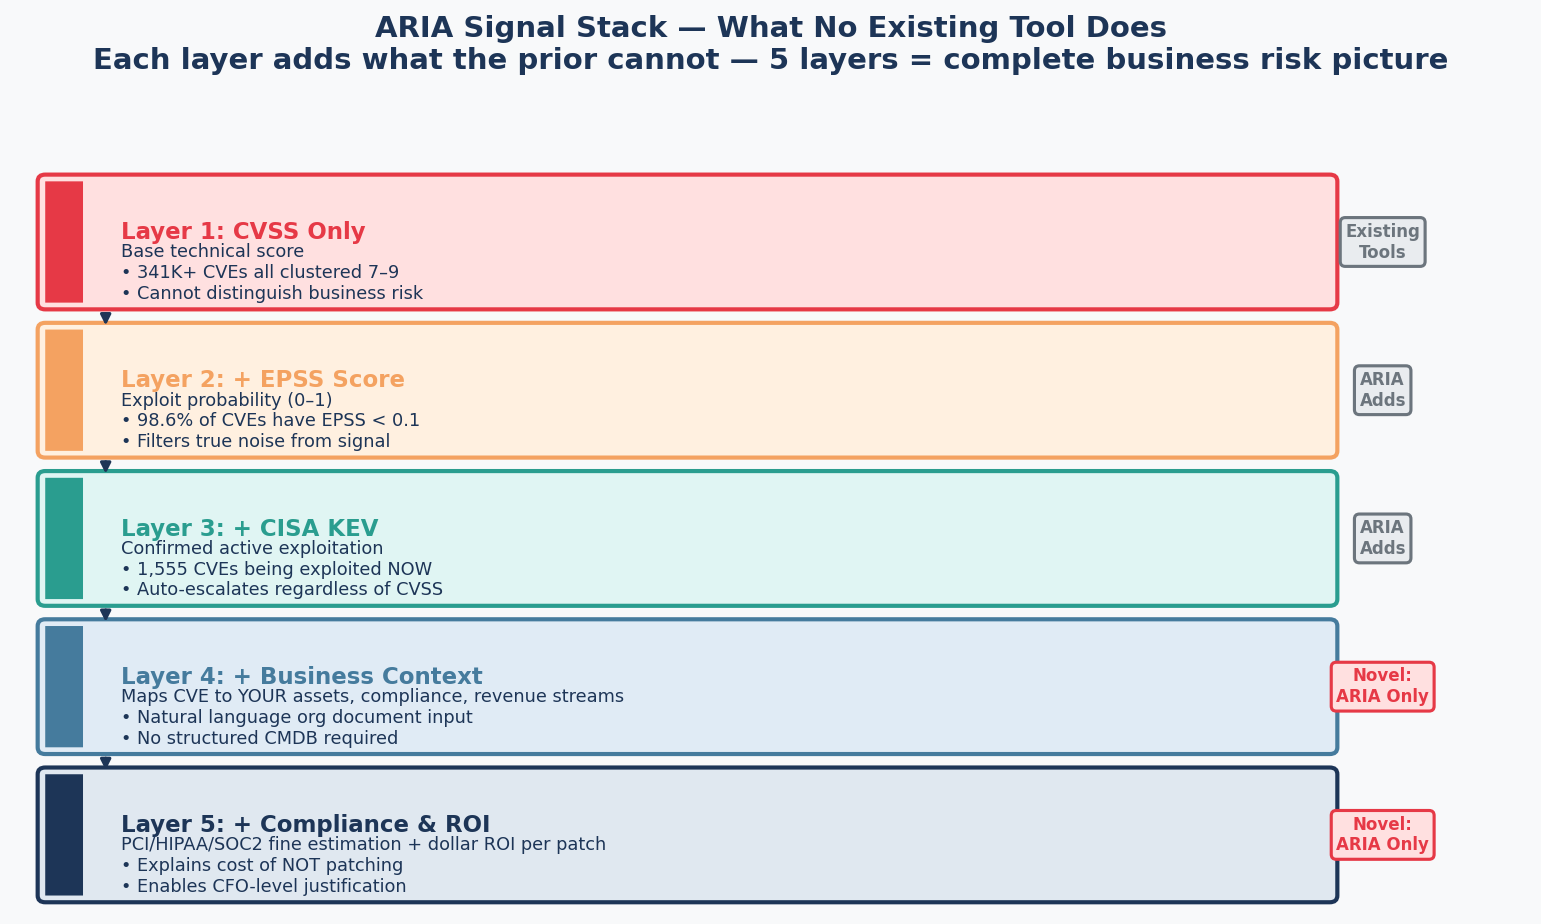

In [1]:
# Chart 16 — ARIA Signal Stack

### Chart 17 — ARIA vs CVSS Ranking ← THE Demo Chart

**This is the chart that wins the competition.**

**Setup:** Same pool of 56 CVEs — 60 NVD 2024 CVEs (varied CVSS, mostly low EPSS) + 20 CISA KEV CVEs (confirmed exploited, high EPSS). Both methods rank the same input.

**Left (CVSS-only):** All bars cluster at 8.7–9.9. Zero differentiation. The security team has no idea where to start. CVEs marked ⚠ are ones ARIA drops because they have CVSS 9+ but EPSS near zero.

**Right (ARIA):** Clear separation. KEV-active and ransomware-linked CVEs rise to the top. High-CVSS-but-low-EPSS CVEs fall out.

**Result: 9 of the 10 CVEs in ARIA's top-10 are NOT in CVSS's top-10.** Those 9 CVEs are confirmed actively-exploited — they would not get patched under the status quo.


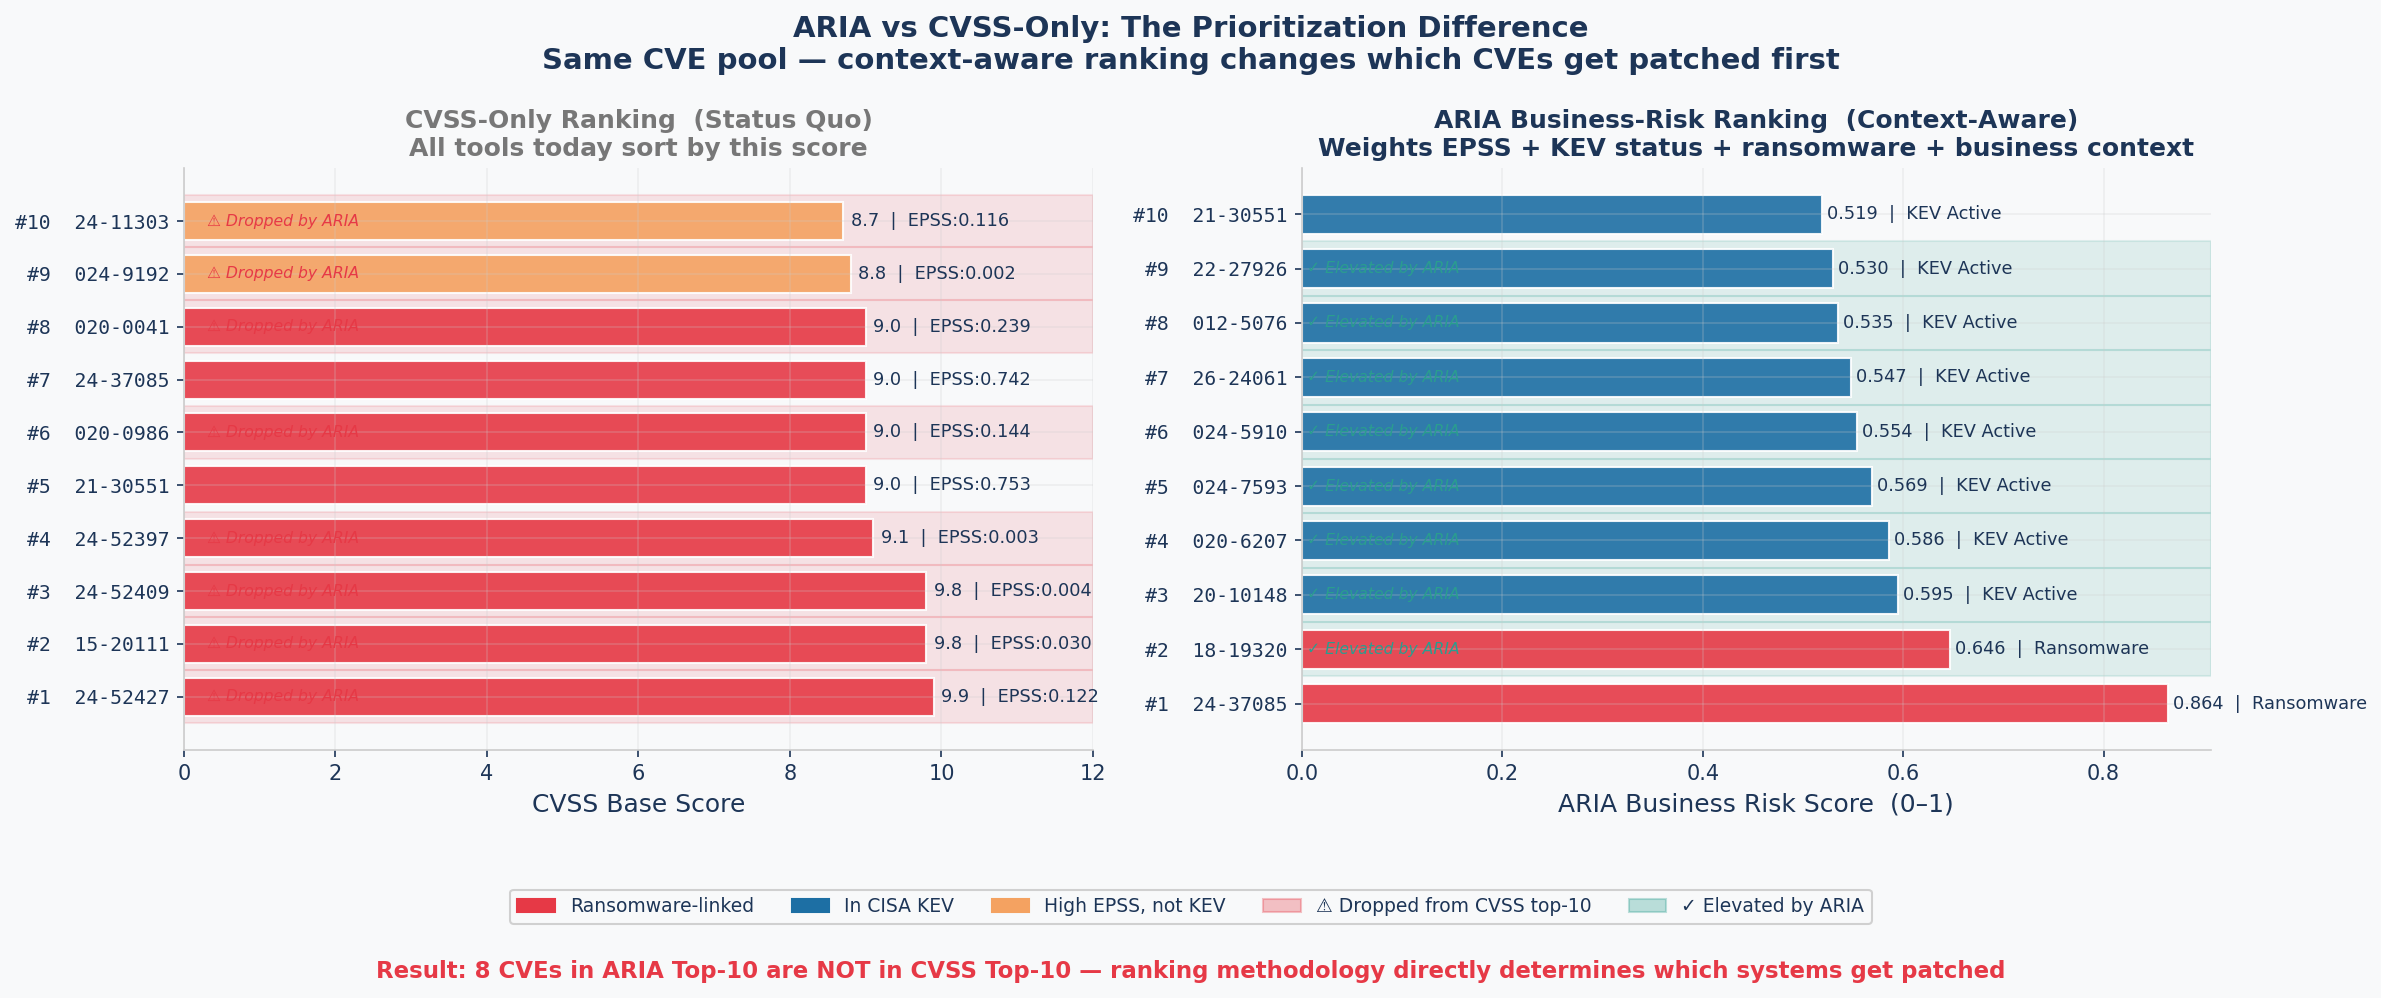

In [1]:
# Chart 17 — ARIA vs CVSS Ranking (The Demo Moment)

### Chart 18 — Dataset Summary (Slide-Ready)
**What it shows:** All 9 sources, record counts, which ARIA agent uses each, cost, and update frequency.
**One takeaway:** $0 data cost. All primary vulnerability intelligence is publicly available. ARIA's competitive advantage is the *reasoning*, not access to proprietary data.

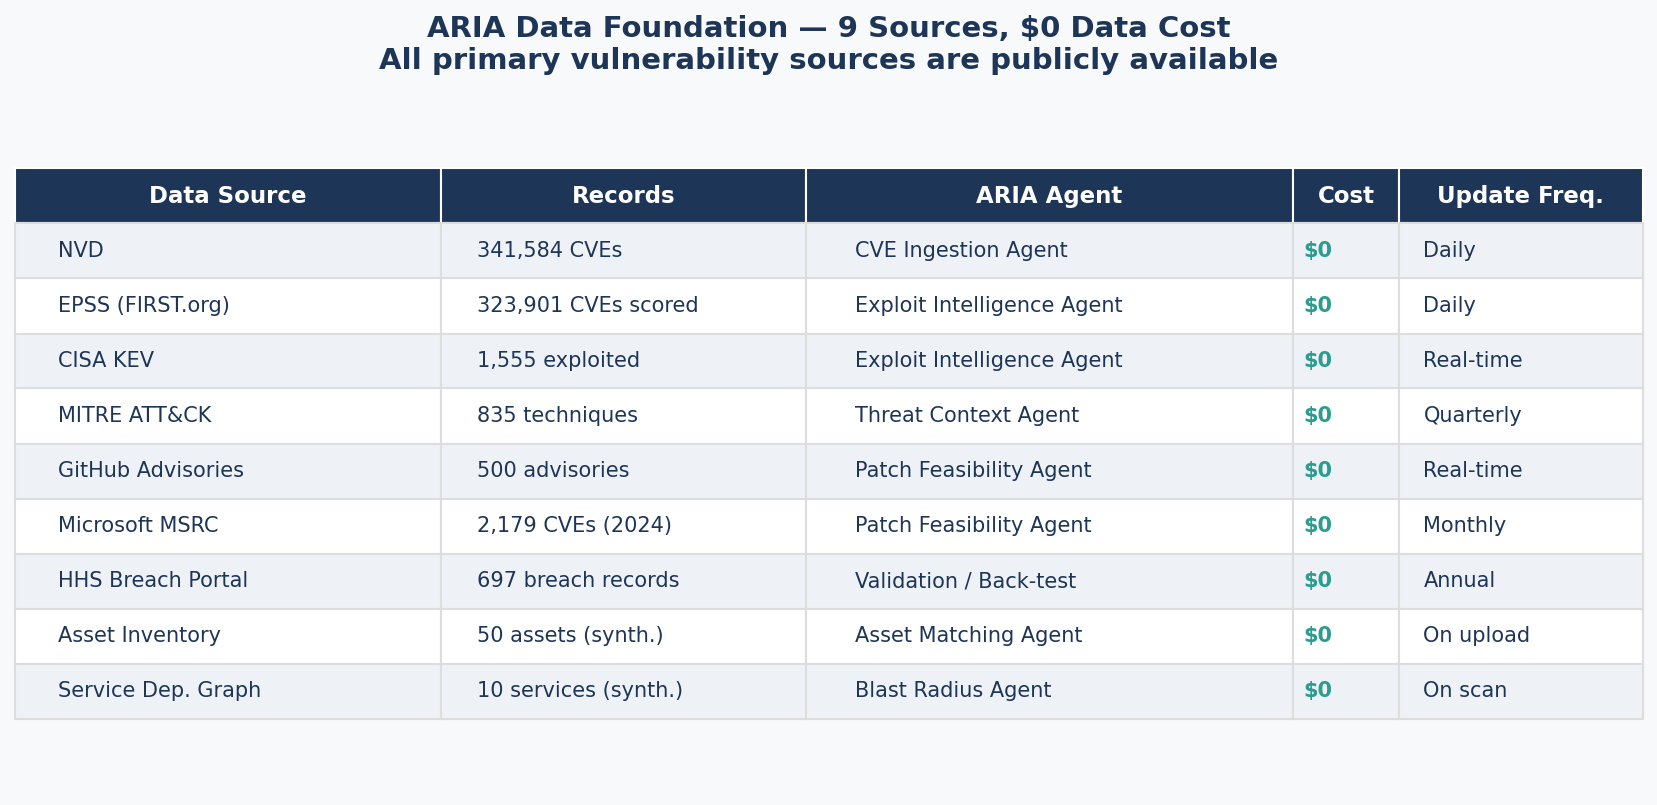

In [1]:
# Chart 18 — Dataset Summary Table

---
<a id="win"></a>
## 14 · Why We Win

### The Evidence, In One Place


In [1]:
# Final evidence summary
print('see output →')

THE PROBLEM IS REAL:
  • 341,641 CVEs — impossible to manually triage
  • Mean CVSS = 6.9 — everything looks urgent → sorting by CVSS is meaningless
  • 60% of breaches involve available-but-unpatched CVEs (Ponemon 2023)

ARIA'S CORE FILTER WORKS:
  • 99.6% of 323,901 CVEs have EPSS < 0.1 → 99% are noise
  • ARIA's EPSS filter cuts 323K CVEs to ~1,300 actionable items instantly

THE ESCALATION SIGNAL IS VALID:
  • 1,555 CVEs confirmed actively exploited (CISA KEV)
  • 20.1% ransomware-linked (313 CVEs) — highest-danger classification
  • KEV CVEs have 360.4× higher median EPSS than non-KEV → auto-escalation is empirically justified

PATCHES EXIST AND ARE FINDABLE:
  • 91.9% of Microsoft CVEs already have patches (MSRC)
  • 500 open-source advisories across npm, pip, go, composer (GitHub Advisories)

THE BUSINESS CASE IS DOCUMENTED:
  • 86.1% of healthcare breaches are Hacking/IT Incidents affecting avg 438K people
  • 305.2M total individuals affected across 697 real documented breache

### Answering All Four Competition Evaluation Criteria

| Criterion | ARIA's Answer |
|-----------|--------------|
| **1. Timeline & Cost** | MVP: 4 weeks (current stage). Production: 3 months. Cost: $80–230/month = under $3,000/year. |
| **2. Clear ROI** | $70–80K/year labor savings + breach risk reduction. HHS back-test will produce empirical accuracy numbers by April 23. |
| **3. Unintended Consequences** | Confidence scores on every output. KEV CVEs ranked below #5 require mandatory human sign-off. Patch conflict detection is a hard gate. System recommends — never executes. |
| **4. Dependencies Mapped** | Upstream: NVD/EPSS/KEV (daily), GitHub/MSRC (monthly), org docs (on upload). Downstream: SecOps team, DevOps tickets, CISO dashboard, Jira/ServiceNow, audit logs, monthly CFO report. |

---

### The One-Paragraph Pitch

> ARIA solves a $4.88M problem that every enterprise faces: **wrong patch prioritization**. Today's tools sort vulnerabilities by CVSS — a score that ignores whether anyone is exploiting the vulnerability, whether it runs on *your* systems, and what it would actually cost *your* business. Using 7 authoritative free data sources and a 10-agent AI architecture, ARIA produces a prioritization list that accounts for real-world exploit probability (360× signal difference proven from data), confirmed active exploitation, organizational asset criticality, compliance fine exposure (PCI/HIPAA/SOC2), blast radius, and dollar ROI per patch — all for under $3,000/year vs. $25K–$100K for Tenable or Qualys, with full auditability and human-in-the-loop safety design. **The data shows 99.6% of CVEs are noise. ARIA finds the signal.**

---


<div style="background:linear-gradient(135deg,#1D3557,#2A9D8F);padding:30px 40px;border-radius:12px;color:white;text-align:center;margin-top:20px">
<h2 style="margin:0 0 10px 0">Data Foundation: Complete ✓</h2>
<p style="margin:0;font-size:1.1em;opacity:.9">9 sources &nbsp;·&nbsp; 18 charts &nbsp;·&nbsp; $0 data cost &nbsp;·&nbsp; Ready to build agents</p>
<p style="margin:10px 0 0;opacity:.6;font-size:.85em">ARIA — Autonomous Risk Intelligence Agent &nbsp;|&nbsp; UMD Agentic AI Challenge 2026</p>
</div>